<a href="https://colab.research.google.com/github/ayman-tech/enso-rl/blob/master/enso-rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Year ENSO using Reinforcement Learning
Running Status :
https://docs.google.com/document/d/1aFqwrrBM45dvgg3tGJ4YikkVkOWF99B6D5AKjOZ9ghc/edit?usp=sharing

In [ ]:
# Download libraries and dataset
import sys
import wandb

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Colab environment")
    wandb.login(key="WANDB_API_KEY")
    %pip install stable-baselines3 cftime XRO shimmy
    %wget -c -P data/ https://github.com/senclimate/XRO/raw/main/data/XRO_indices_oras5.nc

In [2]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import xarray as xr
import cftime
import time
import warnings
import io
import gymnasium as gym
import matplotlib.pyplot as plt

from XRO.core import XRO
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
# from pprint import pprint
# from stable_baselines3.common.env_checker import check_env
# from stable_baselines3.common.evaluation import evaluate_policy

print(f"cftime version: {cftime.__version__}")

cftime version: 1.6.5


In [3]:
# global tunable variables 
threshold = 0.8
debug_mode = True
train_epochs = 12*50*100 # episodes to train for
n_steps =  12*50 # when to reset, set to None for continuous, else episodic train eg 12*50
lr = 0.0003
sim_months = 240
episode_length = None # Reset after episode_length Set to None for continuous (no reset)


In [4]:
# Set wandb API key if not already configured
# wandb.login(key="your_api_key_here")

wandb.init(
    project="enso-rl",
    entity='ayms-university-of-maryland',  # Change to your wandb username if desired
    name="nb-run",
    notes="Training ENSO control using PPO with continuous environment (no episodic resets)",
    tags=["enso", "reinforcement-learning", "ppo", "climate-control"],
)

print("Weights & Biases initialized successfully!")
print(f"View your experiment at: {wandb.run.url}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Aym_s\_netrc.
wandb: Currently logged in as: ayms (ayms-university-of-maryland) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Weights & Biases initialized successfully!
View your experiment at: https://wandb.ai/ayms-university-of-maryland/enso-rl/runs/myle3ubb


In [5]:
def timer(fn): 
    def wrapper(*args, **kwargs): 
        start = time.perf_counter() 
        result = fn(*args, **kwargs) 
        end = time.perf_counter() 
        diff = end-start
        if debug_mode: 
            if diff<60:
                print(f"{fn.__name__}() took {diff:.2f} seconds") 
            else: 
                print(f"{fn.__name__}() took {diff//60} min {diff%60:.2f} sec")

        return result 
    return wrapper

# 1. Getting XRO Model Ready

In [6]:
# XRO package functions give many deprecated warnings & clutter output, disabling them
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.filterwarnings("ignore")

In [ ]:
# Loading observational data (SST, etc.) from https://github.com/senclimate/XRO/blob/main/data/XRO_indices_oras5.nc
if IN_COLAB:
    obs_ds = xr.open_dataset('data/XRO_indices_oras5.nc')
else:
    obs_ds = xr.open_dataset('../data/XRO_indices_oras5.nc')
train_ds = obs_ds.sel(time=slice('1979-01', '2022-12'))
train_ds

<xarray.Dataset> Size: 27kB
Dimensions:  (time: 528)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2022-12-01
    month    (time) int32 2kB ...
Data variables:
    Nino34   (time) float32 2kB ...
    WWV      (time) float32 2kB ...
    NPMM     (time) float32 2kB ...
    SPMM     (time) float32 2kB ...
    IOB      (time) float32 2kB ...
    IOD      (time) float32 2kB ...
    SIOD     (time) float32 2kB ...
    TNA      (time) float32 2kB ...
    ATL3     (time) float32 2kB ...
    SASD     (time) float32 2kB ...

In [8]:
# Variable Names
var_names = list(train_ds.data_vars)

# Set Bounds
bounds = {}
for var in var_names:
    bounds[var] = float(train_ds[var].data.min()),float(train_ds[var].data.max())
bounds

{'Nino34': (-2.5239033699035645, 2.760493278503418),
 'WWV': (-26.161357879638672, 14.945099830627441),
 'NPMM': (-1.0359957218170166, 1.346160888671875),
 'SPMM': (-1.344103217124939, 1.246484398841858),
 'IOB': (-0.582121729850769, 0.8382447361946106),
 'IOD': (-1.3184950351715088, 2.2545392513275146),
 'SIOD': (-1.2861250638961792, 1.2243201732635498),
 'TNA': (-1.1494367122650146, 1.2045494318008423),
 'ATL3': (-1.2200918197631836, 1.3619381189346313),
 'SASD': (-1.4807032346725464, 1.7623258829116821)}

In [9]:
# Initialize model as per https://github.com/senclimate/XRO/blob/main/notebooks/XRO_Cookbook.ipynb
# XRO model in Zhao et al. (2024) is maskb for ENSO's SST and IOD's SST and T*H term in ENSO SST equation, thus maskb=['IOD'], maskNT=['T2', 'TH']
model = XRO()
fitted_params = model.fit_matrix(
    train_ds,
    maskb=['IOD'],
    maskNT=['T2', 'TH']
)

### 1.1 EXTRACT PARAMETERS FROM FITTED MODEL

In [10]:
# Prepare parameters for the RL environment

# Noise Covariance
residuals = fitted_params['Y'] - fitted_params['Yfit']
noise_cov = np.cov(residuals.values, rowvar=True)

# Create the params dictionary
params = {
    'model': model,          # The fitted XRO model object
    'fit_ds': fitted_params, # The fitted parameters dataset
    'noise_cov': noise_cov,  # Covariance matrix
    'var_names': var_names,  # List of variable names
    'dt': 1.0 / 12.0         # Time step
}

print("Parameters extracted successfully.")
print(f"Model: {type(params['model'])}")
print(f"Fitted Params included: {'fit_ds' in params}")

Parameters extracted successfully.
Model: <class 'XRO.core.XRO'>
Fitted Params included: True


### 1.2 PHYSICS FUNCTION (With Annual Cycle)

Prepare the xro_step fn


* First prepare the data into xarray format, because model.simulate needs data in XArray format
* Do simulate for 1 yr(minimum) and extract nxt months state and convert back to array from XArray format.
* Now add the nextState with control_Action = `(action \* Gain_Multiplier) / 12` we assume the action for year
* Also do clip state to prevent large change, and set to 0 if simulate returns NaN values.

**To-Do**
* XRO is an ensemble model so need to check the values. (for now im just taking val of first ensemble members value)

**Why roll the model**

- The XRO.simulate function is "rigid": it always starts simulating from the first index (0) of the parameter dataset it receives.
If we are actually in March (index 2), we need the model to behave like it's March, not January.
- .roll(cycle=-current_month_idx): This rotates the data list backwards. It moves the parameters at index 2 (March) to index 0.
- Result: When the simulator reads the first item, it now finds the March parameters, ensuring the physics match the calendar.

In [11]:
action_scale = [1.8, 0.4, 0.3, 0.3, 0.7, 0.4, 0.35, 0.6, 0.4]
action_scale = [round(x/12,4) for x in action_scale]
print("Action  Scale")
for i in range(len(action_scale)):
    print(f"{var_names[i+1]:<6} : {action_scale[i]}")

Action  Scale
WWV    : 0.15
NPMM   : 0.0333
SPMM   : 0.025
IOB    : 0.025
IOD    : 0.0583
SIOD   : 0.0333
TNA    : 0.0292
ATL3   : 0.05
SASD   : 0.0333


In [12]:
def xro_step(state, params, action, rng, step_idx, xro_debug=False):
    """
    Adds Action (Tuned) to the state and advances the XRO model by
    one month using model.simulate().
    """
    model = params['model']
    current_month_idx = step_idx % 12 # current month index
    # Roll parameters to align with the current calendar month
    fit_ds = params['fit_ds'].roll(
        cycle = -current_month_idx,
        roll_coords = False
    )

    var_names = params['var_names']
    global bounds # Access the global bounds dictionary

    # 1. Apply Control Action
    control_actions = np.zeros_like(state)
    control_actions = action * action_scale
    control_actions = np.insert(control_actions, 0, 0) # add 0 at beginning for nino action = 0

    #  Update State & Safety clip
    updated_state = state + control_actions
    for i, var_name in enumerate(var_names):
        min_val, max_val = bounds[var_name]
        updated_state[i] = np.clip(updated_state[i], min_val, max_val)

    # 2. Prepare Input for XRO.simulate
    # Use scalar values to ensure correct shape (N,) for to_array()
    data_dict = {
        name: float(val)
        for name, val in zip(var_names, updated_state) # var_name : state_var
    }
    input_ds = xr.Dataset(data_dict)


    # 3. Compute Dynamics using model.simulate
    # Use a local seed for reproducibility in this step
    seed = int(rng.integers(0, 1_000_000))
    try:
        prediction_ds = model.simulate(
            fit_ds = fit_ds, # Dataset containing model fit results.
            X0_ds = input_ds, # Initial conditions dataset.
            nyear = 1, # no of simulations : min is 1
            seed = seed
        )

        # 4. Extract the next state (t+1)
        # We take time=0 (first step) and member=0 (default member)
        next_state_ds = prediction_ds.isel(time=0)

        # Handle member dimension if it exists (XRO outputs usually have it)
        if 'member' in next_state_ds.coords or 'member' in next_state_ds.dims:
            next_state_ds = next_state_ds.isel(member=0)

        # FIX: Ensure next_state is always a 1D array of scalars
        next_state = np.array(
            [float(next_state_ds[name]) for name in var_names]
        )

    except Exception as e:
        # Fallback if simulation fails (e.g. instability)
        print(f"Warning: Simulation failed at step {step_idx}. Resetting state. Error: {e}")
        return np.zeros_like(state)

    # 5. Safety Clipping and NaN check
    for i, var_name in enumerate(var_names):
        min_val, max_val = bounds[var_name]
        next_state[i] = np.clip(next_state[i], min_val, max_val)

    # If we still have NaNs (e.g. from the model internals), replace with zeros
    if np.isnan(next_state).any():
        return np.zeros_like(state)

    if xro_debug:
        # print(f'Control Actions : {control_actions}') # DEBUG
        # print(f'State B4 Action : {next_state_natural}') # DEBUG
        # print(f'State Af Action : {next_state}') # DEBUG
        return control_actions, updated_state, next_state

    return next_state

**Why Member dimension is parsed**

XRO simulate's Output contains multiple values of ensemble, currently only first member is used.

In [13]:
def get_data(target_year, target_month):
    """
    Returns the 10 variables of given month and year.
    """
    year_month_data = train_ds.sel(time=f'{target_year}-{target_month:02d}')

    year_month_var_values = []
    for var in var_names:
        year_month_var_values.append(float(year_month_data[var].values.item())) # Using .item() as it's a single value

    return year_month_var_values


In [14]:
from prompt_toolkit.application import current
#-------------------------------------------------
#        IGNORE CELL: CREATED TO TEST xro step fn
#-------------------------------------------------
if debug_mode :
    rng = np.random.default_rng(seed=42) # Random Number Generator

    # 2. Define Initial State (Neutral / Mean State)
    n_vars = len(params['var_names'])
    current_state = get_data(
        target_year = 1979,
        target_month = 1 # January 1979
    )

    # 3. Define Inputs
    action = np.random.normal(loc=0, scale=0.5, size=9) # TUNE SCALE
    step_idx = 0       # January (Month 0)

    # TABLE with DEBUG MODE
    control_actions, updated_state, next_state = xro_step(
        current_state, params, action, rng, step_idx, True
    )
    action_10 = np.insert(action, 0, 0)
    enso_data_3Mean = {
        'Variables': var_names,
        'Action*': action_10,
        'Control_Actions': control_actions,
        'Current_State*': current_state,
        'Updated State': updated_state,
        'Next_State': next_state
    }

    # Create a pandas DataFrame from the dictionary
    df_table = pd.DataFrame(enso_data_3Mean)
    print(df_table.to_string())


  Variables   Action*  Control_Actions  Current_State*  Updated State  Next_State
0    Nino34  0.000000         0.000000       -0.142279      -0.142279   -0.290805
1       WWV -0.414782        -0.062217       11.066086      11.003869   11.816571
2      NPMM -0.439873        -0.014648       -0.253452      -0.268100   -0.333546
3      SPMM -0.276362        -0.006909        0.506946       0.500037    0.497827
4       IOB -0.642206        -0.016055        0.187517       0.171462    0.112587
5       IOD  0.477336         0.027829        0.431726       0.459555    0.216180
6      SIOD  0.042222         0.001406        0.311924       0.313330    0.160257
7       TNA -0.656100        -0.019158        0.233285       0.214127    0.207160
8      ATL3 -0.360329        -0.018016       -0.187185      -0.205202   -0.236731
9      SASD  0.246317         0.008202        0.251324       0.259527    0.217478


# 2. Build the GYM environment
Prepare the gym environment of XRO multi year env

In [15]:
class XROMultiYearEnv(gym.Env):
    """
    CONTINUOUS CLIMATE ENVIRONMENT
    - No artificial episode boundaries
    - Agent learns long-term climate control
    - Preserves multi-year ENSO memory and continuity
    """
    def __init__(self, params, max_steps=None):
        super(XROMultiYearEnv, self).__init__()
        self.params = params
        self.n_modes = len(params['var_names'])
        self.max_steps = max_steps  # None = unlimited (truly continuous)
        self.current_step = 0
        self.rng = np.random.default_rng()

        self.action_space = spaces.Box(
            low = -1.0,
            high = 1.0,
            shape = (9,),
            dtype = np.float32
        )
        # Obs: State + Month (linear 0-1)
        self.observation_space = spaces.Box(
            low = -np.inf,
            high = np.inf,
            shape = (self.n_modes + 1,),
            dtype = np.float32
        )
        self.enso_history = []
        self.consecutive_enso_months = 0  # Track consecutive months in ENSO state
        self.threshold = threshold

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.rng = np.random.default_rng(seed)

        # Generate a random year and month from the available range
        random_year = self.rng.integers(1979, 2022 + 1)
        random_month = self.rng.integers(1, 13) # Months 1-12
        self.state = get_data(random_year, random_month)

        self.current_step = 0
        self.enso_history = [self.state[0]]
        self.consecutive_enso_months = 0  # Reset duration tracker
        return self._get_obs(), {}

    def _get_obs(self):
        """
        Observation Space = [State, month]
        """
        # Normalize month to 0-1 for the agent
        month_feature = (self.current_step % 12) / 12.0
        return np.concatenate([self.state, [month_feature]], dtype=np.float32)

    def step(self, action):
        """
        Step the model with action and add reward (CONTINUOUS - no episode termination)
        """
        # Pass 'self.current_step' to xro_step so it knows the month
        self.state = xro_step(self.state, self.params, action, self.rng, self.current_step)
        self.enso_history.append(self.state[0])

        self.current_step += 1
        
        # Environment only terminates if explicitly stopped externally
        terminated = False
        if self.max_steps is not None and self.current_step >= self.max_steps:
            terminated = True
        
        reward = self._calculate_reward(action)
        

        return self._get_obs(), reward, terminated, False, {}
    
    def _calculate_reward(self, action):
        """
        Calculate reward based on ENSO state and duration.
        Args:
            action (np.ndarray): Control actions taken
        Returns:
            float: Reward value
        """
        enso_index = self.state[0]
        threshold = self.threshold
        # Initialize reward components
        enso_reward = 0.0
        action_penalty = -0.005 * np.sum(np.abs(action) ** 2)
        multi_year_event_reward = 0.0
        duration_reward = 0.0  # Intermediate duration rewards
        duration_penalty = 0.0  # Penalty for excessive persistence

        # 1. Continuous Reward for ENSO Index Values + Duration Tracking
        enso_index = self.state[0] # Nino34 index
        threshold = 1.0
        is_enso_month = False

        if enso_index > threshold:
            enso_reward = 0.1 # Reward for El Niño strength
            self.consecutive_enso_months += 1
            is_enso_month = True
        elif enso_index < -threshold:
            enso_reward = 0.1 # Reward for La Niña strength
            self.consecutive_enso_months += 1
            is_enso_month = True
        else:
            # Break ENSO streak if index falls within threshold
            self.consecutive_enso_months = 0

        # Reward scales with duration: more months = more reward (until penalty kicks in at >30)
        if is_enso_month and self.consecutive_enso_months <= 30:
            if self.consecutive_enso_months >= 24:
                duration_reward += 0.80  # 24+ months: highest reward
            elif self.consecutive_enso_months >= 18:
                duration_reward += 0.25  # 18-23 months: high reward
            elif self.consecutive_enso_months >= 12:
                duration_reward += 0.15  # 12-17 months: medium reward
            elif self.consecutive_enso_months >= 6:
                duration_reward += 0.10  # 6-11 months: base reward

        # Duration Penalty for Unrealistic ENSO Persistence
        elif self.consecutive_enso_months > 30:
            # Linear increasing penalty starting at 30 months
            # At 30 months: -0.05 | At 36 months: -0.11 | At 48 months: -0.23
            duration_reward = -0.01 * (self.consecutive_enso_months - 30)
        
        else : # self.consecutive_enso_months > 36:
            # Steeper penalty; Total at 36: -0.11 | At 48: -0.35 | At 60: -0.59 ?.,mnbvcxz v
            extra_penalty = -0.02 * (self.consecutive_enso_months - 36)
            duration_reward += extra_penalty

        # 3. Multi-year event reward (continuous check, not just at termination)
        # Allows agent to learn about long-term events as they develop
        # if self.current_step % 12 == 0:  # Check every year
        #     if self._check_multi_year_event(self.enso_history):
        #         multi_year_event_reward = 0.5  # Distributed reward throughout event

        # Combine all reward components
        reward = enso_reward + multi_year_event_reward + duration_reward + duration_penalty + action_penalty
        return reward

    def _check_multi_year_event(self, history):
        """
        Check if for at least 2 years, the enso index is beyond threshold
        """
        history = np.array(history)
        min_duration = 24 # at least 2 years for multi-year event

        # El Nino Check
        is_nino = (history >= threshold).astype(int) # check all history > thres
        if self._max_run_length(is_nino) >= min_duration:
            return True

        # La Nina Check
        is_nina = (history <= -threshold).astype(int)
        if self._max_run_length(is_nina) >= min_duration:
            return True

        return False

    @staticmethod
    def _max_run_length(binary_sequence):
        """Calculate longest consecutive run of 1s in binary sequence."""
        padded = np.concatenate(([0], binary_sequence, [0]))
        changes = np.diff(padded)
        starts = np.where(changes == 1)[0]
        ends = np.where(changes == -1)[0]
        
        if len(starts) == 0:
            return 0
        
        return (ends - starts).max()


In [16]:
# Custom W&B Callback for PPO Training
class WandbCallback(BaseCallback):
    """
    Custom callback that logs PPO training metrics to Weights & Biases in real-time.
    """
    def __init__(self, verbose=0):
        super(WandbCallback, self).__init__(verbose)
        self.num_timesteps_last_logged = 0

    def _on_step(self) -> bool:
        """Called after every step in the environment."""
        
        # Log to W&B every 100 timesteps
        if self.num_timesteps >= self.num_timesteps_last_logged + 100:
            log_dict = {}
            
            # Basic timestep and episode info
            log_dict['timesteps'] = self.num_timesteps
            
            # Get episode info from buffer if available
            if hasattr(self.model, 'ep_info_buffer') and len(self.model.ep_info_buffer) > 0:
                # Get the latest episode
                latest_ep = self.model.ep_info_buffer[-1]
                log_dict['episode_reward'] = latest_ep.get('r', 0)
                log_dict['episode_length'] = latest_ep.get('l', 0)
                log_dict['episodes'] = len(self.model.ep_info_buffer)
            
            # Log metrics from the model logger if available
            if hasattr(self.model, 'logger') and self.model.logger is not None:
                # The logger stores key-value pairs in name_to_value
                if hasattr(self.model.logger, 'name_to_value'):
                    mean_dict = self.model.logger.name_to_value
                    if mean_dict:
                        for key, value in mean_dict.items():
                            if isinstance(value, (int, float)):
                                # Clean up key names
                                clean_key = key.replace('/', '_')
                                log_dict[clean_key] = value
            
            # Log FPS if available
            if hasattr(self.model, 'start_time') and self.model.start_time:
                import time
                elapsed = time.time() - self.model.start_time
                if elapsed > 0:
                    log_dict['fps'] = int(self.num_timesteps / elapsed)
            
            # Only log if we have something to log (more than just timesteps)
            if len(log_dict) > 1:
                wandb.log(log_dict)
                if self.verbose > 0:
                    print(f"[WandbCallback] Logged metrics at {self.num_timesteps} timesteps")
            
            self.num_timesteps_last_logged = self.num_timesteps
        
        return True

    def _on_training_end(self) -> None:
        """Called when training ends."""
        log_dict = {
            'training_complete': True,
            'final_timesteps': self.num_timesteps
        }
        wandb.log(log_dict, step=self.num_timesteps)
        if self.verbose > 0:
            print(f"[WandbCallback] Training completed! Final timesteps: {self.num_timesteps}")


In [17]:
# CONTINUOUS TRAINING: PPO learns long-term climate control without episodic resets

# Log hyperparameters to W&B
hyperparameters = {
    "algorithm": "PPO",
    "policy": "MlpPolicy",
    "total_timesteps": train_epochs,
    "env_max_steps": episode_length,
    "action_space_dim": 9,
    "observation_space_dim": 11,
    "action_scale": action_scale,
    "enso_threshold": threshold,
    "debug_mode": debug_mode,
}
wandb.config.update(hyperparameters)
wandb.log({"training_config": hyperparameters})

# Capture verbose output from training
output_buffer = io.StringIO()
old_stdout = sys.stdout
sys.stdout = output_buffer

# Train PPO model on CONTINUOUS environment (no artificial episode boundaries)
env = XROMultiYearEnv(params=params, max_steps=episode_length)  # max_steps=None for unlimited continuous training (doesnt reset)

# Create PPO model with W&B callback
model_ppo = PPO(policy="MlpPolicy", 
                env = env,
                learning_rate=lr,
                n_steps=n_steps, # update weights after n_steps months
                verbose=1)

# Train with W&B callback
wandb_callback = WandbCallback(verbose=1)
model_ppo.learn(total_timesteps=train_epochs, callback=wandb_callback)

sys.stdout = old_stdout
verbose_output = output_buffer.getvalue()

# Parse verbose output into structured metrics
lines = verbose_output.split('\n')
metrics_list = []
current_update = {}

for line in lines:
    if not line.strip() or '---' in line or '===' in line: # Skip empty lines and separator lines
        if current_update:
            # metrics_list.append(current_update)
            current_update = {}
        continue
    
    # Parse metric lines (format: | metric_name | value |)
    if '|' in line:
        parts = [p.strip() for p in line.split('|')]
        # Filter out empty parts
        parts = [p for p in parts if p]
        
        # Handle two-column format (metric_name | value)
        if len(parts) == 2:
            metric_name = parts[0]
            try:
                value = float(parts[1])
                # Clean up metric name (remove category prefix)
                clean_name = metric_name.replace('episode/', '').replace('train/', '').replace('time/', '')
                current_update[clean_name] = value
            except (ValueError, IndexError):
                pass

# Add last update if exists
if current_update:
    metrics_list.append(current_update)

# Create DataFrame with all metrics
if metrics_list:
    df_verbose_metrics = pd.DataFrame(metrics_list)
    
    # Reorder columns for better readability
    col_order = ['iterations', 'total_timesteps', 'fps', 'ep_rew_mean', 'ep_len_mean', 
                 'policy_gradient_loss', 'loss', 'value_loss', 'approx_kl', 'clip_fraction',
                 'entropy_loss', 'explained_variance', 'std', 'learning_rate', 'n_updates']
    
    # Keep only columns that exist
    col_order = [col for col in col_order if col in df_verbose_metrics.columns]
    df_verbose_metrics = df_verbose_metrics[col_order]
    
    # Display
    pd.set_option('display.float_format', lambda x: f'{x:.6f}')
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    print("\n" + "="*180)
    print("PPO CONTINUOUS TRAINING")
    print("="*180)
    print(df_verbose_metrics.to_string(index=False))
    print("="*180)
    print(f"Total updates captured: {len(df_verbose_metrics)}")
    
    # Log training metrics table to W&B
    wandb.log({
        "training_metrics_table": wandb.Table(dataframe=df_verbose_metrics),
        "total_training_updates": len(df_verbose_metrics)
    })

# Save model to W&B artifacts
model_save_path = "ppo_enso_model"
model_ppo.save(model_save_path)
wandb.save(f"{model_save_path}.zip")

# Log model as artifact
artifact = wandb.Artifact(
    name=f"ppo-enso-model-{wandb.run.id}",
    type="model",
    description="Trained PPO model for ENSO climate control"
)
artifact.add_file(f"{model_save_path}.zip")
wandb.log_artifact(artifact)

print(f"\n✓ Model saved and logged to W&B!")


wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.



✓ Model saved and logged to W&B!


**Ideal Training Trajectory:**

- ep_rew_mean        📈 then ➡️
- explained_variance 📈 → 0.9+
- approx_kl          ➡️ stable ~0.015
- clip_fraction      ➡️ ~0.15–0.25
- entropy/std        📉 slowly
- value_loss         📉

## 6. Evaluation and Comparison

We compare the frequency of multi-year events between:
1. **No Control**: Action = 0
2. **RL Agent**: Action = Policy


In [18]:
def _find_continuous_runs(binary_sequence):
    """
    Find all continuous runs of 1s in a binary sequence.
    
    Args:
        binary_sequence (np.ndarray): Binary array of 0s and 1s
        
    Returns:
        list: List of tuples (start_idx, end_idx, length) for each run of 1s
    """
    padded = np.concatenate(([0], binary_sequence, [0]))
    changes = np.diff(padded)
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0] - 1
    
    runs = []
    for start, end in zip(starts, ends):
        runs.append((start, end, end - start + 1))
    
    return runs

def classify_enso_event(enso_history, threshold=1.0, min_duration=24):
    """
    Classifies each month in ENSO history into different event types.
    
    Args:
        enso_history (list or np.ndarray): List/array of ENSO index values over time
        threshold (float): Magnitude threshold for El Nino/La Nina
        min_duration (int): Minimum months for multi-year event
        
    Returns:
        np.ndarray: Array of classifications for each month
                   ('Neutral', 'Single-year El Nino', 'Single-year La Nina',
                    'Multi-year El Nino', 'Multi-year La Nina')
    """
    enso_history = np.array(enso_history)
    n_months = len(enso_history)
    
    # Initialize all as neutral
    classifications = np.array(['Neutral'] * n_months, dtype=object)
    
    # Identify El Niño and La Niña periods
    is_nino = (enso_history >= threshold).astype(int)
    is_nina = (enso_history <= -threshold).astype(int)
    
    # Find continuous runs for El Niño
    nino_runs = _find_continuous_runs(is_nino)
    for start, end, length in nino_runs:
        if length >= min_duration:
            classifications[start:end+1] = 'Multi-year El Nino'
        elif length >= 12:
            classifications[start:end+1] = 'Single-year El Nino'
    
    # Find continuous runs for La Niña
    nina_runs = _find_continuous_runs(is_nina)
    for start, end, length in nina_runs:
        if length >= min_duration:
            classifications[start:end+1] = 'Multi-year La Nina'
        elif length >= 12:
            classifications[start:end+1] = 'Single-year La Nina'
    
    return classifications

def summarize_classification(classifications_array):
    """
    Create a summary string showing percentages of all event types.
    
    Args:
        classifications_array (np.ndarray): Array of classifications for each month
        
    Returns:
        str: Summary with percentages (e.g., "Multi-year El Nino: 45.5%, Multi-year La Nina: 20.3%, ...")
    """
    from collections import Counter
    
    total_months = len(classifications_array)
    if total_months == 0:
        return 'No data'
    
    # Count all event types
    counts = Counter(classifications_array)
    
    # Calculate percentages for all events, sorted by count descending
    event_percentages = []
    for event, count in sorted(counts.items(), key=lambda x: -x[1]):
        percentage = (count / total_months) * 100
        event_percentages.append(f"{event}: {percentage:.1f}%")
    
    return ", ".join(event_percentages)

print("`classify_enso_event`, `_find_continuous_runs`, and `summarize_classification` defined successfully.")

`classify_enso_event`, `_find_continuous_runs`, and `summarize_classification` defined successfully.


In [19]:
def evaluate_agent(env, agent=None, continuous_steps=6000):
    """
    Evaluate agent performance over continuous steps.
    
    Args:
        env: Gymnasium environment
        agent: Trained agent (if None, uses zero actions)
        continuous_steps (int): Number of steps to evaluate
        
    Returns:
        float: Probability of multi-year events (percentage of months in 24+ month events)
    """
    
    enso_history = []
    obs, _ = env.reset()
    enso_history.append(obs[0])
    
    for step in range(continuous_steps):
        if agent:
            action, _ = agent.predict(obs, deterministic=True)
        else:
            action = np.zeros(9)
        
        obs, reward, terminated, truncated, _ = env.step(action)
        enso_history.append(obs[0])
    
    # Classify events and calculate multi-year probability
    classified = classify_enso_event(enso_history, threshold=env.threshold, min_duration=24)
    mye_months = np.sum((classified == 'Multi-year El Nino') | (classified == 'Multi-year La Nina'))
    mye_probability = mye_months / len(classified)
    
    return mye_probability

# Evaluate both scenarios - continuous 500-year simulations
print("=" * 70)
print("MULTI-YEAR ENSO EVENT PROBABILITY COMPARISON")
print("=" * 70)

prob_with_control = evaluate_agent(env, agent=model_ppo, continuous_steps=6000)
print(f"\nWith RL Agent Control:    {prob_with_control:.1%}")

prob_without_control = evaluate_agent(env, agent=None, continuous_steps=6000)
print(f"Without Control (Baseline): {prob_without_control:.1%}")

improvement = (prob_with_control - prob_without_control) * 100
print(f"\nImprovement: {improvement:+.1f} percentage points")
print("=" * 70)

# Log evaluation results to W&B
evaluation_results = {
    "evaluation/multi_year_events_with_agent": prob_with_control,
    "evaluation/multi_year_events_without_agent": prob_without_control,
    "evaluation/improvement_percentage_points": improvement,
    "evaluation/improvement_ratio": prob_with_control / prob_without_control if prob_without_control > 0 else 1.0,
    "evaluation/steps": 6000,
}
wandb.log(evaluation_results)
wandb.log({"evaluation_complete": True})

print(f"\n✓ Evaluation results logged to W&B!")


MULTI-YEAR ENSO EVENT PROBABILITY COMPARISON

With RL Agent Control:    0.4%
Without Control (Baseline): 7.0%

Improvement: -6.6 percentage points

✓ Evaluation results logged to W&B!


In [20]:
@timer
def simulate(
    env,
    agent=None,
    no_months=6000,
    disable_control_for_idx=None
):
    global action_scale
    simulation_data = []
    obs, _ = env.reset()
    sim_enso_history = [obs[0]]
    actions_history = []
    states_history = [obs[:-1]]
    total_rewards = 0.0
    if debug_mode:
        if disable_control_for_idx: 
            print(f"Starting Simulation with disabled {var_names[disable_control_for_idx+1]} actions for {no_months/12} years...")
        else : print(f"Starting Simulation for {no_months/12} years...")

    for step in range(no_months):
        if agent:
            action, _ = agent.predict(obs, deterministic=True)
        else:
            action = np.zeros(env.action_space.shape)
        if disable_control_for_idx is not None:
            action[disable_control_for_idx] = 0.0
            
        scaled_action = action * action_scale
        actions_history.append(scaled_action)
        obs, reward, terminated, truncated, _ = env.step(action)
        
        total_rewards += reward
        sim_enso_history.append(obs[0])
        states_history.append(obs[:-1])  # Store state (excluding month)
    
    classified_event_array = classify_enso_event(sim_enso_history)
    classified_event_type = summarize_classification(classified_event_array)
    avg_reward = total_rewards / no_months
    mye_months = np.sum((classified_event_array == 'Multi-year El Nino') | (classified_event_array == 'Multi-year La Nina'))
    mye_prob = mye_months / len(classified_event_array) if len(classified_event_array) > 0 else 0.0

    simulation_data = {
        'no_months': len(sim_enso_history) - 1,
        'enso_traj': np.array(sim_enso_history),
        'classified_event_array': classified_event_array,
        'actions_traj': np.array(actions_history),
        'states_traj': np.array(states_history),
        'classified_event': classified_event_type,
        'avg_reward' : avg_reward,
        "mye_months": mye_months,
        "mye_probablity": mye_prob
    }
    if debug_mode:
        print(f"✓ Simulated {len(sim_enso_history)-1} months")
        print(f"Avg Reward: {avg_reward:.4f}")

    return simulation_data


### Plot
Simulates single episode using the trained Reinforcement Learning agent (model_ppo) and then visualizes the outcome. Record the evolution of the ENSO index (the first component of the state) and the corresponding control actions taken by the agent over the course of the episode.

2 plots are generated:
1. **Sample Controlled ENSO Trajectory**: This plot of how the ENSO index changes month by month under the influence of the RL agent's actions. It includes horizontal lines indicating the typical thresholds for El Niño (0.8) and La Niña (-0.8) events, allowing you to see how the agent's control affects these phenomena.
2. **Control Actions**: This plot displays the sequence of control actions applied by the agent throughout the simulated episode.

Starting Simulation for 20.0 years...
✓ Simulated 240 months
Avg Reward: 0.7097
simulate() took 4.52 seconds


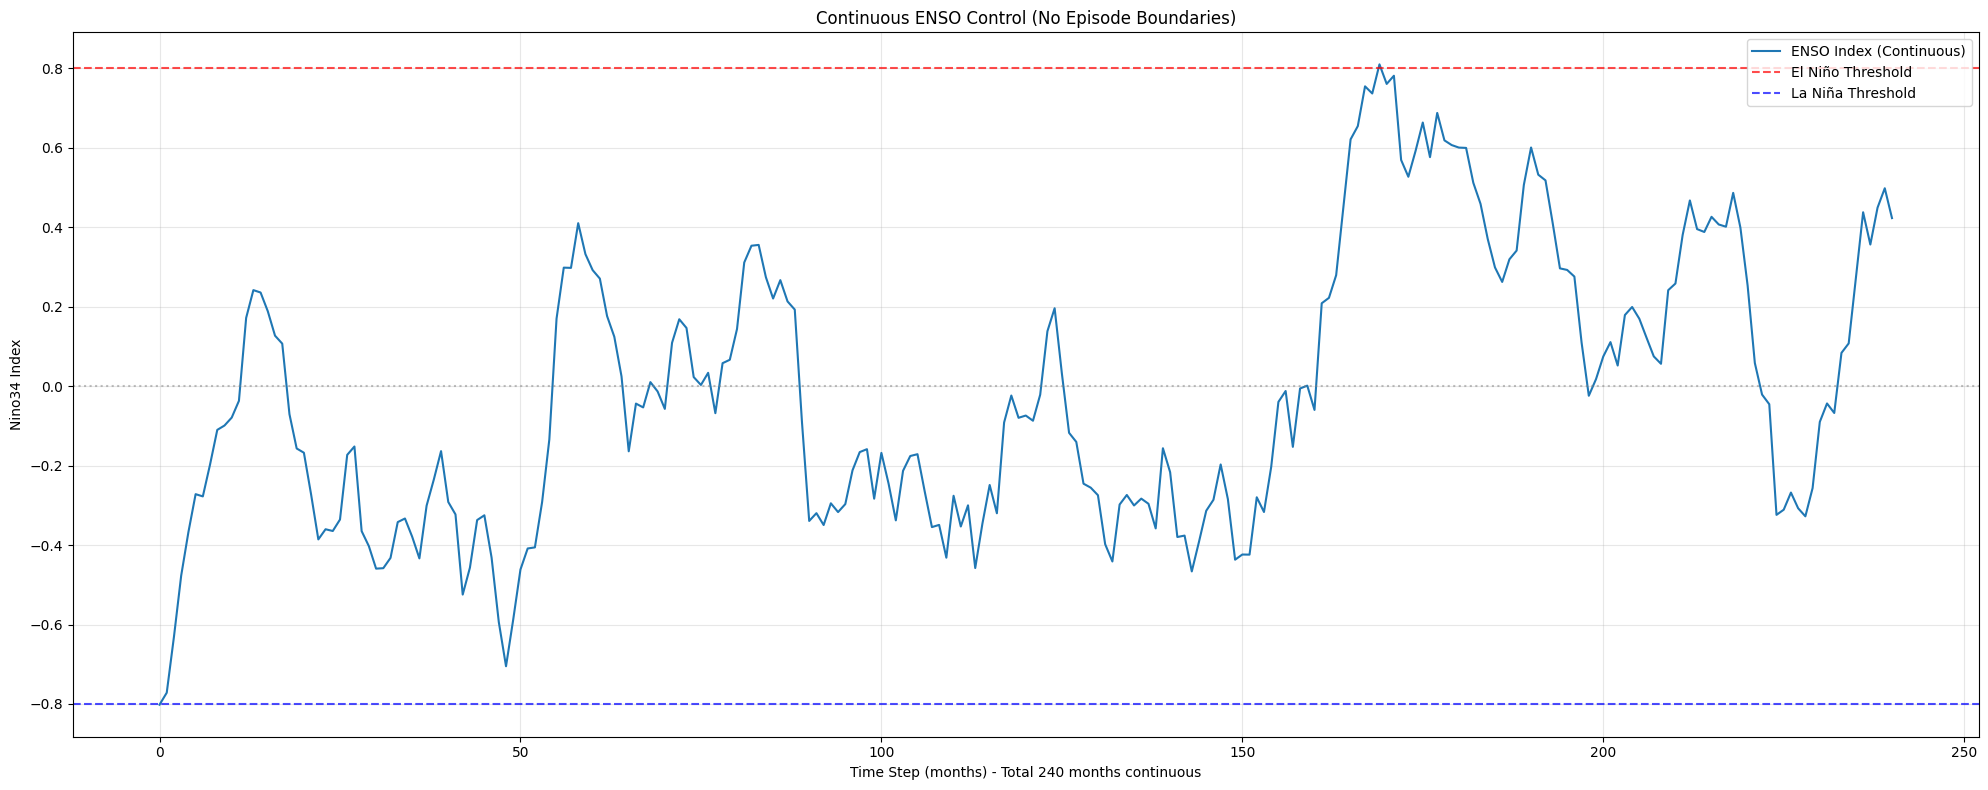

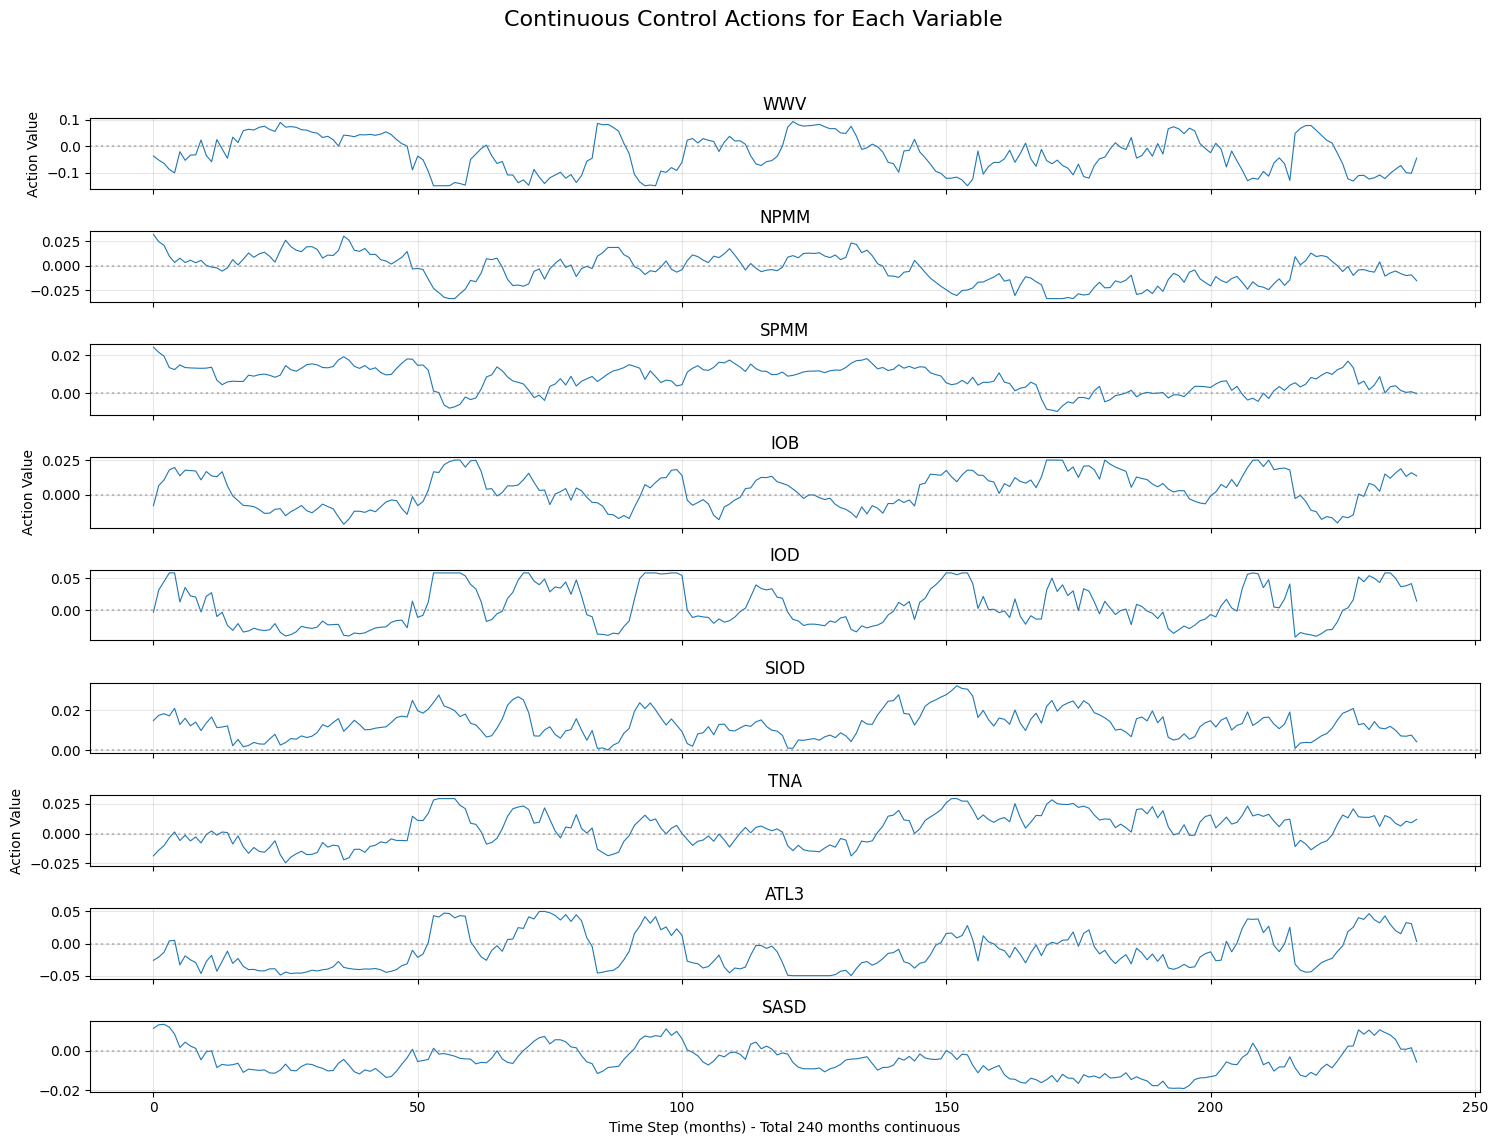

In [21]:
# CONTINUOUS SIMULATION: No artificial episode boundaries or resets
# This preserves the full climate history and agent's learned long-term strategies
global threshold
sim_data = simulate(
    env=env,
    agent=model_ppo,
    no_months=sim_months,
    disable_control_for_idx=None,
)

# --- Plotting Continuous Trajectory ---

# Main figure for ENSO trajectory (CONTINUOUS - no episode breaks)
plt.figure(figsize=(20, 8))
plt.plot(sim_data['enso_traj'], linewidth=1.5, label='ENSO Index (Continuous)')
plt.axhline(threshold, color='r', linestyle='--', label='El Niño Threshold', alpha=0.7)
plt.axhline(-threshold, color='b', linestyle='--', label='La Niña Threshold', alpha=0.7)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.title("Continuous ENSO Control (No Episode Boundaries)")
plt.xlabel(f"Time Step (months) - Total {sim_data['no_months']} months continuous")
plt.ylabel("Nino34 Index")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a figure for all action variables in separate subplots (CONTINUOUS)
num_actions = sim_data['actions_traj'].shape[1] # Get number of actions from the continuous array
fig2, axes = plt.subplots(nrows=9, ncols=1, figsize=(15, 12), sharex=True)
fig2.suptitle("Continuous Control Actions for Each Variable", fontsize=16)

axes = axes.flatten() # Flatten the array of axes for easy iteration

for i in range(num_actions):
    axes[i].plot(sim_data['actions_traj'][:, i], linewidth=0.8) # Plot from the continuous array
    axes[i].set_title(f'{var_names[i+1]}') # Using var_names for titles
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='gray', linestyle=':', alpha=0.5)
    if i == num_actions-1: # Add x-label only for bottom row plots
        axes[i].set_xlabel(f"Time Step (months) - Total {sim_data['no_months']} months continuous")
    if i % 3 == 0: # Add y-label only for left-most column plots
        axes[i].set_ylabel("Action Value")

# Hide any unused subplots
for j in range(num_actions, len(axes)):
    if j < len(axes):
        fig2.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


<Figure size 2000x800 with 0 Axes>

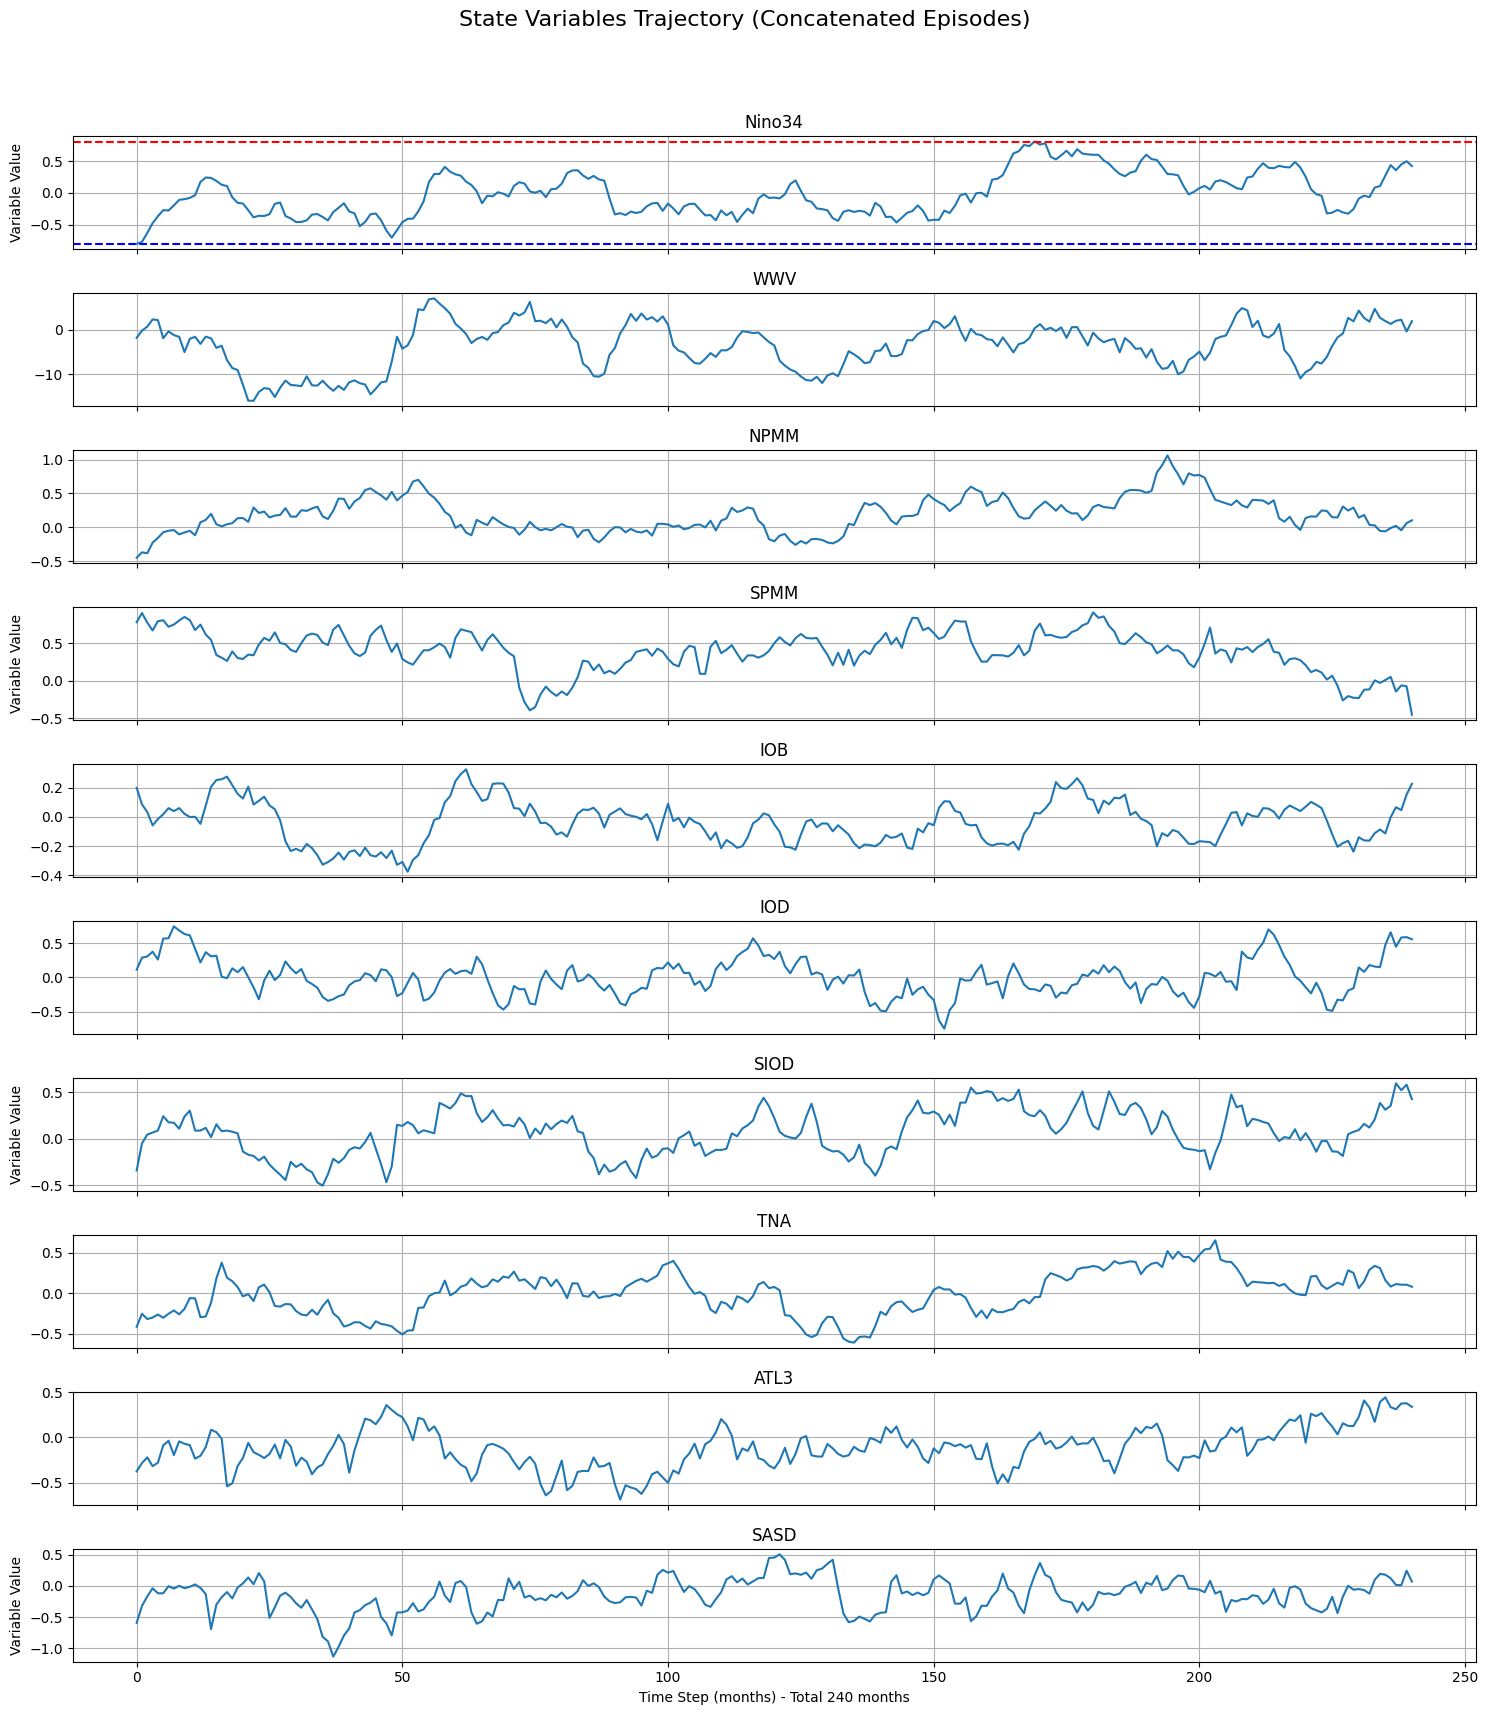

In [22]:
# --- Plotting Concatenated Episodes ---

# Main figure for ENSO trajectory (concatenated episodes)
plt.figure(figsize=(20, 8))

# Create a figure for all state variables in separate subplots (concatenated episodes)
num_variables = sim_data['states_traj'].shape[1] # Get number of variables from the concatenated array
fig2, axes = plt.subplots(nrows=num_variables, ncols=1, figsize=(15, 18), sharex=True) # Increased figsize for 10 plots
fig2.suptitle("State Variables Trajectory (Concatenated Episodes)", fontsize=16)

axes = axes.flatten() # Flatten the array of axes for easy iteration

for i in range(num_variables):
    axes[i].plot(sim_data['states_traj'][:, i]) # Plot from the concatenated array
    axes[i].set_title(f'{var_names[i]}') # Using var_names for titles (no +1 needed as it's the variables themselves)
    axes[i].grid(True)
    if(i==0):
        axes[i].axhline(threshold, color='r', linestyle='--', label='El Nino Thr')
        axes[i].axhline(-threshold, color='b', linestyle='--', label='La Nina Thr')
    if i == num_variables -1: # Add x-label only for the last plot
        axes[i].set_xlabel(f"Time Step (months) - Total {sim_data['no_months']} months")
    if i % 3 == 0 or i == 0: # Add y-label for every third plot or the first one
        axes[i].set_ylabel("Variable Value")

# Hide any unused subplots (not strictly necessary if nrows=num_variables and ncols=1)
for j in range(num_variables, len(axes)):
    if j < len(axes):
        fig2.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [23]:
from IPython.display import display
import pandas as pd
import numpy as np

# Calculate 3-month running mean (centered)
# min_periods=2 allows calculation at edges (t=0 uses t, t+1; t=end uses t-1, t)
enso_data_3Mean = pd.Series(sim_data['enso_traj']).rolling(window=3, center=True, min_periods=2).mean().values

# 2. Reshape into (Years x 12 Months)
n_months = 12
n_years = len(enso_data_3Mean) // n_months

# Truncate data to fit full years
data_full_years = enso_data_3Mean[:n_years * n_months]
reshaped_data = data_full_years.reshape(n_years, n_months)

# 3. Create DataFrame
months = ['DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND', 'NDJ']
df_enso = pd.DataFrame(reshaped_data, columns=months)
df_enso.index.name = 'Year \\'
# Adjust index to start from 1 (or specific year if known)
df_enso.index = df_enso.index + 1

# 4. Define Styling Function
def color_enso_values(val):
    """
    Colors values > 1 in Red, and < 1 in Blue.
    """
    # color = 'black'
    color = 'white'
    if val > 1.0:
        color = 'red'
    elif val < -1.0:
        # color = 'blue'
        color = 'lightblue'
    return f'color: {color}'

# 5. Apply Style and Format
# We use .map() (pandas >= 2.1.0) or .applymap() for older versions
styler = df_enso.style.format("{:.2f}") # Format to 2 decimal places

try:
    styler = styler.map(color_enso_values)
except AttributeError:
    styler = styler.applymap(color_enso_values)

# Display the styled table explicitly
display(styler)

,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
Year \,,,,,,,,,,,,
1,-0.79,-0.73,-0.63,-0.49,-0.37,-0.31,-0.25,-0.19,-0.14,-0.10,-0.07,0.02
2,0.13,0.22,0.22,0.18,0.14,0.05,-0.04,-0.13,-0.20,-0.28,-0.34,-0.37
3,-0.35,-0.29,-0.22,-0.23,-0.31,-0.41,-0.44,-0.45,-0.41,-0.37,-0.35,-0.38
4,-0.37,-0.32,-0.23,-0.23,-0.26,-0.38,-0.43,-0.44,-0.37,-0.36,-0.45,-0.58
5,-0.63,-0.58,-0.49,-0.43,-0.37,-0.28,-0.09,0.11,0.26,0.34,0.35,0.35
6,0.30,0.25,0.19,0.11,-0.00,-0.06,-0.09,-0.03,-0.02,-0.02,0.01,0.07
7,0.14,0.11,0.06,0.02,-0.01,0.01,0.02,0.09,0.17,0.27,0.34,0.33
8,0.28,0.25,0.23,0.22,0.11,-0.08,-0.25,-0.34,-0.32,-0.32,-0.30,-0.28
9,-0.22,-0.18,-0.20,-0.20,-0.23,-0.25,-0.27,-0.24,-0.19,-0.20,-0.26,-0.32


# Interventional Driver Analysis,

Create a function `run_simulation_with_intervention` to evaluate the RL agent's performance (total reward and multi-year event probability) with specific control actions optionally disabled. This function will be the core of the analysis, allowing for the quantification of each feature's impact on the overall outcome.

### Perform Baseline Evaluation

Run the `run_simulation_with_intervention` function using the trained `model_ppo` without any disabled actions to establish a baseline for average reward and multi-year event probability. This represents E[R | π].


In [24]:
# CONTINUOUS BASELINE SIMULATION (no intervention, full agent control)
baseline_sim_data = simulate(
    env=env,
    agent=model_ppo,
    no_months=1200, # 100 yrs 
    disable_control_for_idx=None,  # No action disabled - full control
)
baseline_reward = sim_data['avg_reward']
baseline_mye_probablity = sim_data['mye_probablity']

print(f"\n{'='*80}")
print(f"BASELINE (Full Control - No Action Disabled):")
print(f"{'='*80}")
print(f"Baseline Average Reward (E[R | π]): {sim_data['avg_reward']:.2f}")
print(f"Baseline Multi-Year ENSO Event: {sim_data['mye_probablity']:.2%}")
print(f"Total continuous months simulated: {sim_data['no_months']}")


Starting Simulation for 100.0 years...
✓ Simulated 1200 months
Avg Reward: 0.6886
simulate() took 23.60 seconds

BASELINE (Full Control - No Action Disabled):
Baseline Average Reward (E[R | π]): 0.71
Baseline Multi-Year ENSO Event: 0.00%
Total continuous months simulated: 240


### Implement Intervention Loop

Iterate through each feature. For each feature, call `run_simulation_with_intervention` with the corresponding control action disabled (set to zero). This will give $$E[R | a_i=0]$$ for each feature i.


In [25]:
intervention_results = []

# The controllable variables start from index 1 in var_names (WWV, NPMM, etc.)
controllable_vars = var_names[1:]  # Skip 'Nino34'

print(f"\n{'='*80}")
print(f"INTERVENTION ANALYSIS")
print(f"{'='*80}")
print(f"Testing {len(controllable_vars)} controllable variables...")

for i, feature_name in enumerate(controllable_vars):
    print(f"\n--- Testing Impact of {feature_name} (Action Index: {i}) ---")
    
    disabled_sim_data = simulate(
        env=env,
        agent=model_ppo,
        no_months=1200,
        disable_control_for_idx=i,
    )
    
    intervention_results.append({
        'feature': feature_name,
        'avg_reward': disabled_sim_data['avg_reward'],
        'multi_year_prob': disabled_sim_data['mye_probablity'],
        'enso_history': disabled_sim_data['enso_traj']
    })
    
    delta_r = disabled_sim_data['avg_reward'] - baseline_reward
    impact = "⬇️ REDUCES reward" if delta_r < 0 else "⬆️ INCREASES reward" if delta_r > 0 else "≈ NO change"
    
    print(f"  Average Reward: {disabled_sim_data['avg_reward']:.4f}")
    print(f"  Delta R (vs baseline): {delta_r:.4f} {impact}")
    print(f"  Multi-Year Event Probability: {disabled_sim_data['mye_probablity']:.2%}")

print(f"\n{'='*80}")
print("Intervention Results Summary:")
print(f"{'='*80}")
for result in intervention_results:
    delta_r = result['avg_reward'] - baseline_reward
    print(f"Feature: {result['feature']:<10} | Avg Reward: {result['avg_reward']:>8.4f} | Delta R: {delta_r:>8.4f} | Multi-Year: {result['multi_year_prob']:.2%}")



INTERVENTION ANALYSIS
Testing 9 controllable variables...

--- Testing Impact of WWV (Action Index: 0) ---
Starting Simulation for 100.0 years...
✓ Simulated 1200 months
Avg Reward: 0.6830
simulate() took 23.50 seconds
  Average Reward: 0.6830
  Delta R (vs baseline): -0.0267 ⬇️ REDUCES reward
  Multi-Year Event Probability: 0.00%

--- Testing Impact of NPMM (Action Index: 1) ---
Starting Simulation with disabled NPMM actions for 100.0 years...
✓ Simulated 1200 months
Avg Reward: 0.6984
simulate() took 21.00 seconds
  Average Reward: 0.6984
  Delta R (vs baseline): -0.0113 ⬇️ REDUCES reward
  Multi-Year Event Probability: 0.00%

--- Testing Impact of SPMM (Action Index: 2) ---
Starting Simulation with disabled SPMM actions for 100.0 years...
✓ Simulated 1200 months
Avg Reward: 0.6798
simulate() took 20.71 seconds
  Average Reward: 0.6798
  Delta R (vs baseline): -0.0299 ⬇️ REDUCES reward
  Multi-Year Event Probability: 0.00%

--- Testing Impact of IOB (Action Index: 3) ---
Starting Si

## Calculate Delta R Metric

For each feature, calculate the Delta R $$ ΔR_i = E[R | a_i=0] - E[R | π] $$

Large negative ΔR => feature is a strong driver.


In [26]:
delta_r_values = []

for result in intervention_results:
    delta_r = result['avg_reward'] - baseline_reward
    delta_r_values.append({
        'feature': result['feature'],
        'delta_r': delta_r,
        'avg_reward': result['avg_reward']
    })

print(f"\n{'='*80}")
print("Delta R Analysis (Impact of Disabling Each Action):")
print(f"{'='*80}")
print(f"Baseline Reward (full control): {baseline_reward:.4f}\n")

for item in sorted(delta_r_values, key=lambda x: x['delta_r']):
    direction = "⬇️ CRITICAL" if item['delta_r'] < -0.01 else "⬆️ POSITIVE" if item['delta_r'] > 0.01 else "≈ NEUTRAL"
    print(f"{item['feature']:<10} | ΔR: {item['delta_r']:>8.4f} {direction}")



Delta R Analysis (Impact of Disabling Each Action):
Baseline Reward (full control): 0.7097

SPMM       | ΔR:  -0.0299 ⬇️ CRITICAL
IOB        | ΔR:  -0.0281 ⬇️ CRITICAL
WWV        | ΔR:  -0.0267 ⬇️ CRITICAL
SASD       | ΔR:  -0.0252 ⬇️ CRITICAL
TNA        | ΔR:  -0.0202 ⬇️ CRITICAL
IOD        | ΔR:  -0.0139 ⬇️ CRITICAL
ATL3       | ΔR:  -0.0116 ⬇️ CRITICAL
NPMM       | ΔR:  -0.0113 ⬇️ CRITICAL
SIOD       | ΔR:  -0.0052 ≈ NEUTRAL


In [27]:
sorted_delta_r_vals = sorted(delta_r_values, key=lambda x: x['delta_r'])
flag = True
print("\n--- Features (Most Imp -> Least Imp) ---\n")

for item in sorted_delta_r_vals:
    print(item['feature'], end=' ')
    if flag and item['delta_r']>=0:
        print('| ', end='')
        flag = False

del flag, sorted_delta_r_vals


--- Features (Most Imp -> Least Imp) ---

SPMM IOB WWV SASD TNA IOD ATL3 NPMM SIOD 

## Visualize Intervention Results

Generate a bar chart showing the calculated Delta R values for each feature.


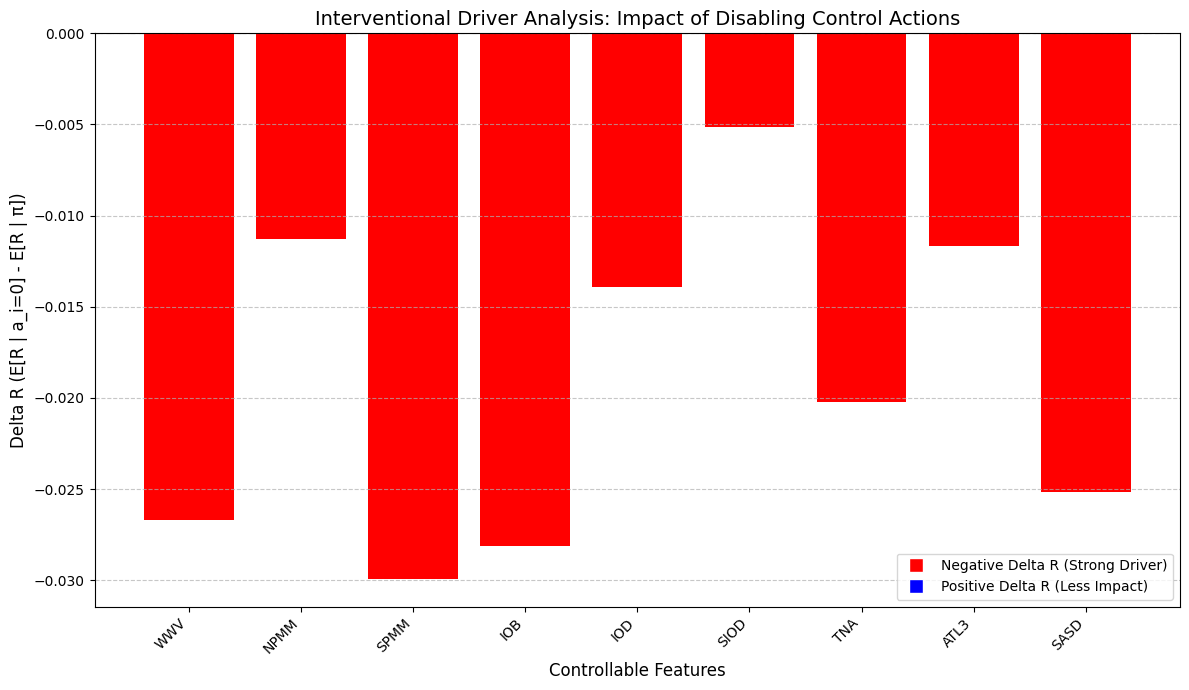

In [28]:
import matplotlib.pyplot as plt

# 1. Extract feature names and delta_r values
features = [item['feature'] for item in delta_r_values]
delta_r_vals = [item['delta_r'] for item in delta_r_values]

# 2. Create a bar chart
plt.figure(figsize=(12, 7))

# 3. Assign different colors based on positive or negative Delta R
colors = ['red' if dr < 0 else 'blue' for dr in delta_r_vals]
plt.bar(features, delta_r_vals, color=colors)

# 4. Add a horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--')

# 5. Label axes
plt.xlabel('Controllable Features', fontsize=12)
plt.ylabel('Delta R (E[R | a_i=0] - E[R | \u03c0])', fontsize=12)

# 6. Add a title
plt.title('Interventional Driver Analysis: Impact of Disabling Control Actions', fontsize=14)

# 7. Include a legend
# Create dummy artists for the legend
red_patch = plt.Line2D([0], [0], marker='s', color='w', label='Negative Delta R (Strong Driver)',
                          markerfacecolor='red', markersize=10)
blue_patch = plt.Line2D([0], [0], marker='s', color='w', label='Positive Delta R (Less Impact)',
                           markerfacecolor='blue', markersize=10)
plt.legend(handles=[red_patch, blue_patch])

# Improve layout and display
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Task
- Analyze the RL agent's actions and environmental variable behaviors across different ENSO event categories.
- Implement a helper function `classify_enso_event` to categorize ENSO history into:
    1. 'Multi-year El Nino'
    2. 'Multi-year La Nina'
    3. 'Single-year El Nino'
    4. 'Single-year La Nina'
    5. 'Neutral'

- Run multiple simulation episodes using the trained RL model, collecting `enso_history`, `actions`, `state` observations, and the `classified_event_type` for each.
- Aggregate this data by ENSO event category. Calculate and present summary statistics (mean, median, std, min, max) for each of 9 actions and 10 variables within each ENSO event category.
- Generate Kernel Density Estimate (KDE) plots for each action and environmental variable, showing overlaid distributions for each ENSO event category.
- summarize key findings and patterns observed in action-taking and variable behavior across the different ENSO event types and their durations.

In [29]:
# Advanced W&B Features: Custom Charts and Comparisons

# 1. Create custom chart for comparing metrics
if 'df_verbose_metrics' in locals() and len(df_verbose_metrics) > 0:
    # Create normalized comparison of key metrics
    metrics_to_compare = ['ep_rew_mean', 'value_loss', 'approx_kl', 'explained_variance']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for metric in metrics_to_compare:
        if metric in df_verbose_metrics.columns:
            normalized_metric = (df_verbose_metrics[metric] - df_verbose_metrics[metric].min()) / (df_verbose_metrics[metric].max() - df_verbose_metrics[metric].min() + 1e-10)
            ax.plot(df_verbose_metrics['iterations'], normalized_metric, label=metric, linewidth=2, marker='o', markersize=4)
    
    ax.set_xlabel('Training Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Metric Value', fontsize=12, fontweight='bold')
    ax.set_title('Normalized Training Metrics Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    wandb.log({"metrics_comparison": wandb.Image(fig)})
    plt.show()
else:
    print("⚠ df_verbose_metrics not available - skipping metrics comparison chart")

# 2. Log environment parameters as configuration
environment_config = {
    "env_type": "XROMultiYearEnv",
    "env_max_steps": 120,
    "continuous": True,
    "climate_model": "XRO",
    "enso_threshold": threshold,
    "action_penalty_weight": 0.01,
    "multi_year_event_reward": 0.5,
    "duration_penalty_start": 30,
}
wandb.config.update(environment_config)

# 3. Log model capability information
model_info = {
    "model_type": "PPO",
    "policy_network": "MlpPolicy",
    "hidden_layers": "Default SB3",
    "learning_rate": "0.0003",  # Default SB3 PPO
    "gamma": "0.99",  # Default SB3
    "gae_lambda": "0.95",  # Default SB3
}
wandb.log({
    "model_architecture": wandb.Table(
        data=[[k, v] for k, v in model_info.items()],
        columns=["Parameter", "Value"]
    )
})

# 4. Create comparison table: with vs without control
comparison_data = [
    ["Metric", "With Agent", "Without Agent", "Improvement"],
    ["Multi-Year Event %", f"{prob_with_control:.1%}", f"{prob_without_control:.1%}", f"{improvement:+.1f}pp"],
    ["Control Type", "RL Agent", "Zero Action", "RL Beats Baseline"],
]

wandb.log({
    "performance_comparison": wandb.Table(
        data=comparison_data[1:],
        columns=comparison_data[0]
    )
})

print("✓ Advanced W&B features logged!")
print("  - Custom metric comparison chart")
print("  - Environment configuration")
print("  - Model architecture details")
print("  - Performance comparison table")


⚠ df_verbose_metrics not available - skipping metrics comparison chart
✓ Advanced W&B features logged!
  - Custom metric comparison chart
  - Environment configuration
  - Model architecture details
  - Performance comparison table


## Modify Simulation Function to Collect Comprehensive Data

### Subtask:
Adapt the existing `run_simulation_with_intervention` or create a new simulation loop. This loop will run multiple episodes using the trained RL model and collect, for each episode, the full `enso_history`, all `actions` taken, all `state` observations, and the `classified_event_type` using the function from the previous step.


**Reasoning**:
I will define the `run_data_collection_simulation` function as specified in the subtask instructions. This function will simulate multiple episodes, collect the required data (ENSO history, actions, states), and classify the ENSO event for each episode.



In [30]:
# CONTINUOUS DATA COLLECTION (No artificial episode boundaries)
continuous_simulation_months = 1200  # 100 years of continuous climate simulation

sim_data = simulate(
    env=env,
    agent=model_ppo,
    no_months=continuous_simulation_months,
)

print(f"\nCollected continuous data: {sim_data['no_months']} months")
print(f"Classified ENSO event: {sim_data['classified_event']}")
print(f"Data structure keys: {sim_data.keys()}")


Starting Simulation for 100.0 years...
✓ Simulated 1200 months
Avg Reward: 0.6792
simulate() took 19.49 seconds

Collected continuous data: 1200 months
Classified ENSO event: Neutral: 100.0%
Data structure keys: dict_keys(['no_months', 'enso_traj', 'classified_event_array', 'actions_traj', 'states_traj', 'classified_event', 'avg_reward', 'mye_months', 'mye_probablity'])


In [31]:
# CONTINUOUS DATA ANALYSIS
# Extract continuous trajectory data


print(f"\nAnalyzing continuous ENSO control simulation...")
print(f"  Total duration: {sim_data['no_months']} months ({sim_data['no_months'] // 12} years)")
print(f"  Overall classification: {sim_data['classified_event']}")

# Extract time series
enso_index_ts = sim_data['enso_traj']
actions_ts = sim_data['actions_traj']
states_ts = sim_data['states_traj']

# Calculate continuous statistics
action_names = controllable_vars
state_var_names = var_names

# Summary statistics over entire continuous simulation
summary_stats_actions = {}
summary_stats_states = {}

for i, name in enumerate(action_names):
    col_data = actions_ts[:, i]
    summary_stats_actions[name] = {
        'mean': np.mean(col_data),
        'median': np.median(col_data),
        'std': np.std(col_data),
        'min': np.min(col_data),
        'max': np.max(col_data),
        'total_steps': len(col_data)
    }

for i, name in enumerate(state_var_names):
    col_data = states_ts[:, i]
    summary_stats_states[name] = {
        'mean': np.mean(col_data),
        'median': np.median(col_data),
        'std': np.std(col_data),
        'min': np.min(col_data),
        'max': np.max(col_data),
        'total_steps': len(col_data)
    }

print("\n" + "="*80)
print("Summary Statistics for Control Actions (Continuous Simulation):")
print("="*80)



Analyzing continuous ENSO control simulation...
  Total duration: 1200 months (100 years)
  Overall classification: Neutral: 100.0%

Summary Statistics for Control Actions (Continuous Simulation):


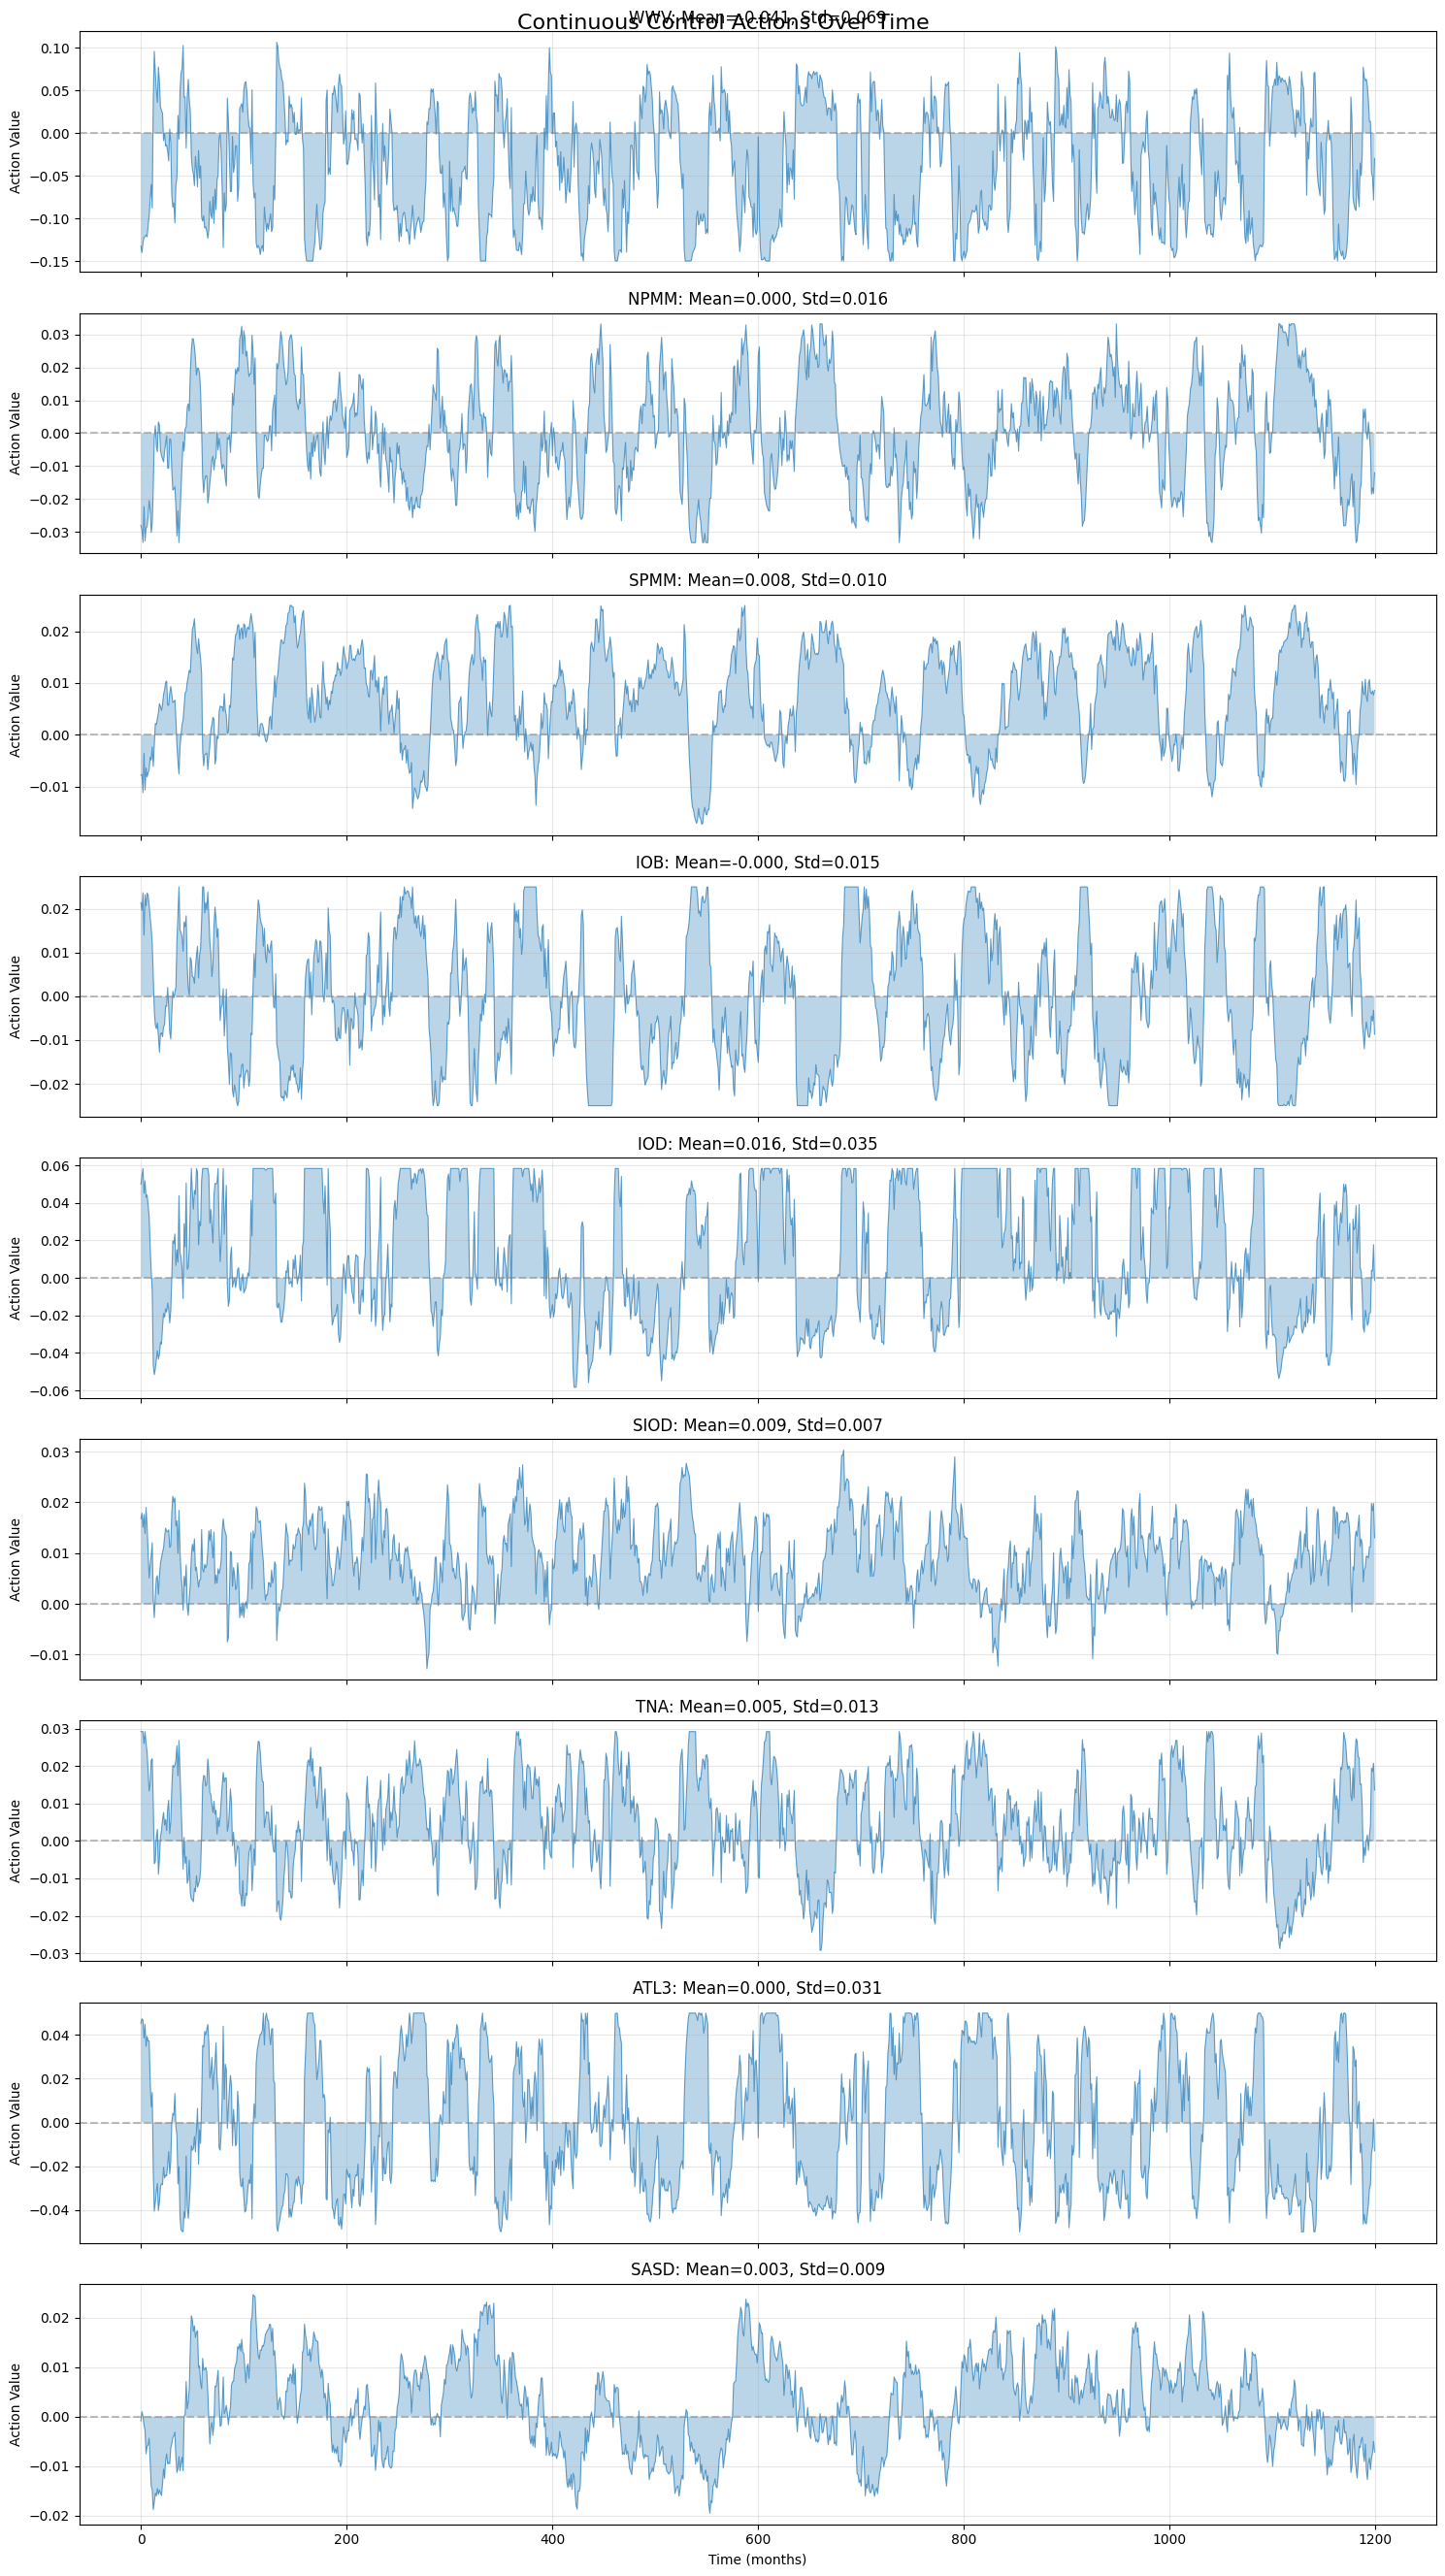


Continuous Action Time Series Statistics:

WWV:
  mean: -0.0412
  median: -0.0454
  std: 0.0688
  min: -0.1500
  max: 0.1062
  total_steps: 1200.0000

NPMM:
  mean: 0.0002
  median: -0.0000
  std: 0.0165
  min: -0.0333
  max: 0.0333
  total_steps: 1200.0000

SPMM:
  mean: 0.0077
  median: 0.0083
  std: 0.0096
  min: -0.0173
  max: 0.0250
  total_steps: 1200.0000

IOB:
  mean: -0.0001
  median: -0.0012
  std: 0.0152
  min: -0.0250
  max: 0.0250
  total_steps: 1200.0000

IOD:
  mean: 0.0156
  median: 0.0129
  std: 0.0348
  min: -0.0583
  max: 0.0583
  total_steps: 1200.0000

SIOD:
  mean: 0.0095
  median: 0.0092
  std: 0.0074
  min: -0.0128
  max: 0.0303
  total_steps: 1200.0000

TNA:
  mean: 0.0046
  median: 0.0047
  std: 0.0132
  min: -0.0292
  max: 0.0292
  total_steps: 1200.0000

ATL3:
  mean: 0.0003
  median: -0.0038
  std: 0.0314
  min: -0.0500
  max: 0.0500
  total_steps: 1200.0000

SASD:
  mean: 0.0025
  median: 0.0027
  std: 0.0093
  min: -0.0195
  max: 0.0246
  total_steps: 12

In [32]:
# CONTINUOUS SIMULATION: Time Series Visualization of Actions
import seaborn as sns

# Plot continuous time series of actions
num_actions = len(action_names)
fig_actions, axes_actions = plt.subplots(nrows=num_actions, ncols=1, figsize=(15, num_actions * 3), sharex=True)
fig_actions.suptitle('Continuous Control Actions Over Time', fontsize=16)

if num_actions == 1:
    axes_actions = [axes_actions]

for i, action_name in enumerate(action_names):
    ax = axes_actions[i]
    action_ts = actions_ts[:, i]
    
    ax.plot(action_ts, linewidth=0.8, alpha=0.7)
    ax.fill_between(range(len(action_ts)), action_ts, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{action_name}: Mean={summary_stats_actions[action_name]["mean"]:.3f}, Std={summary_stats_actions[action_name]["std"]:.3f}')
    ax.set_ylabel('Action Value')
    ax.grid(True, alpha=0.3)

axes_actions[-1].set_xlabel('Time (months)')
fig_actions.tight_layout()
plt.show()

print("\nContinuous Action Time Series Statistics:")
for name, stats in summary_stats_actions.items():
    print(f"\n{name}:")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value:.4f}" if isinstance(value, (int, float)) else f"  {stat_name}: {value}")


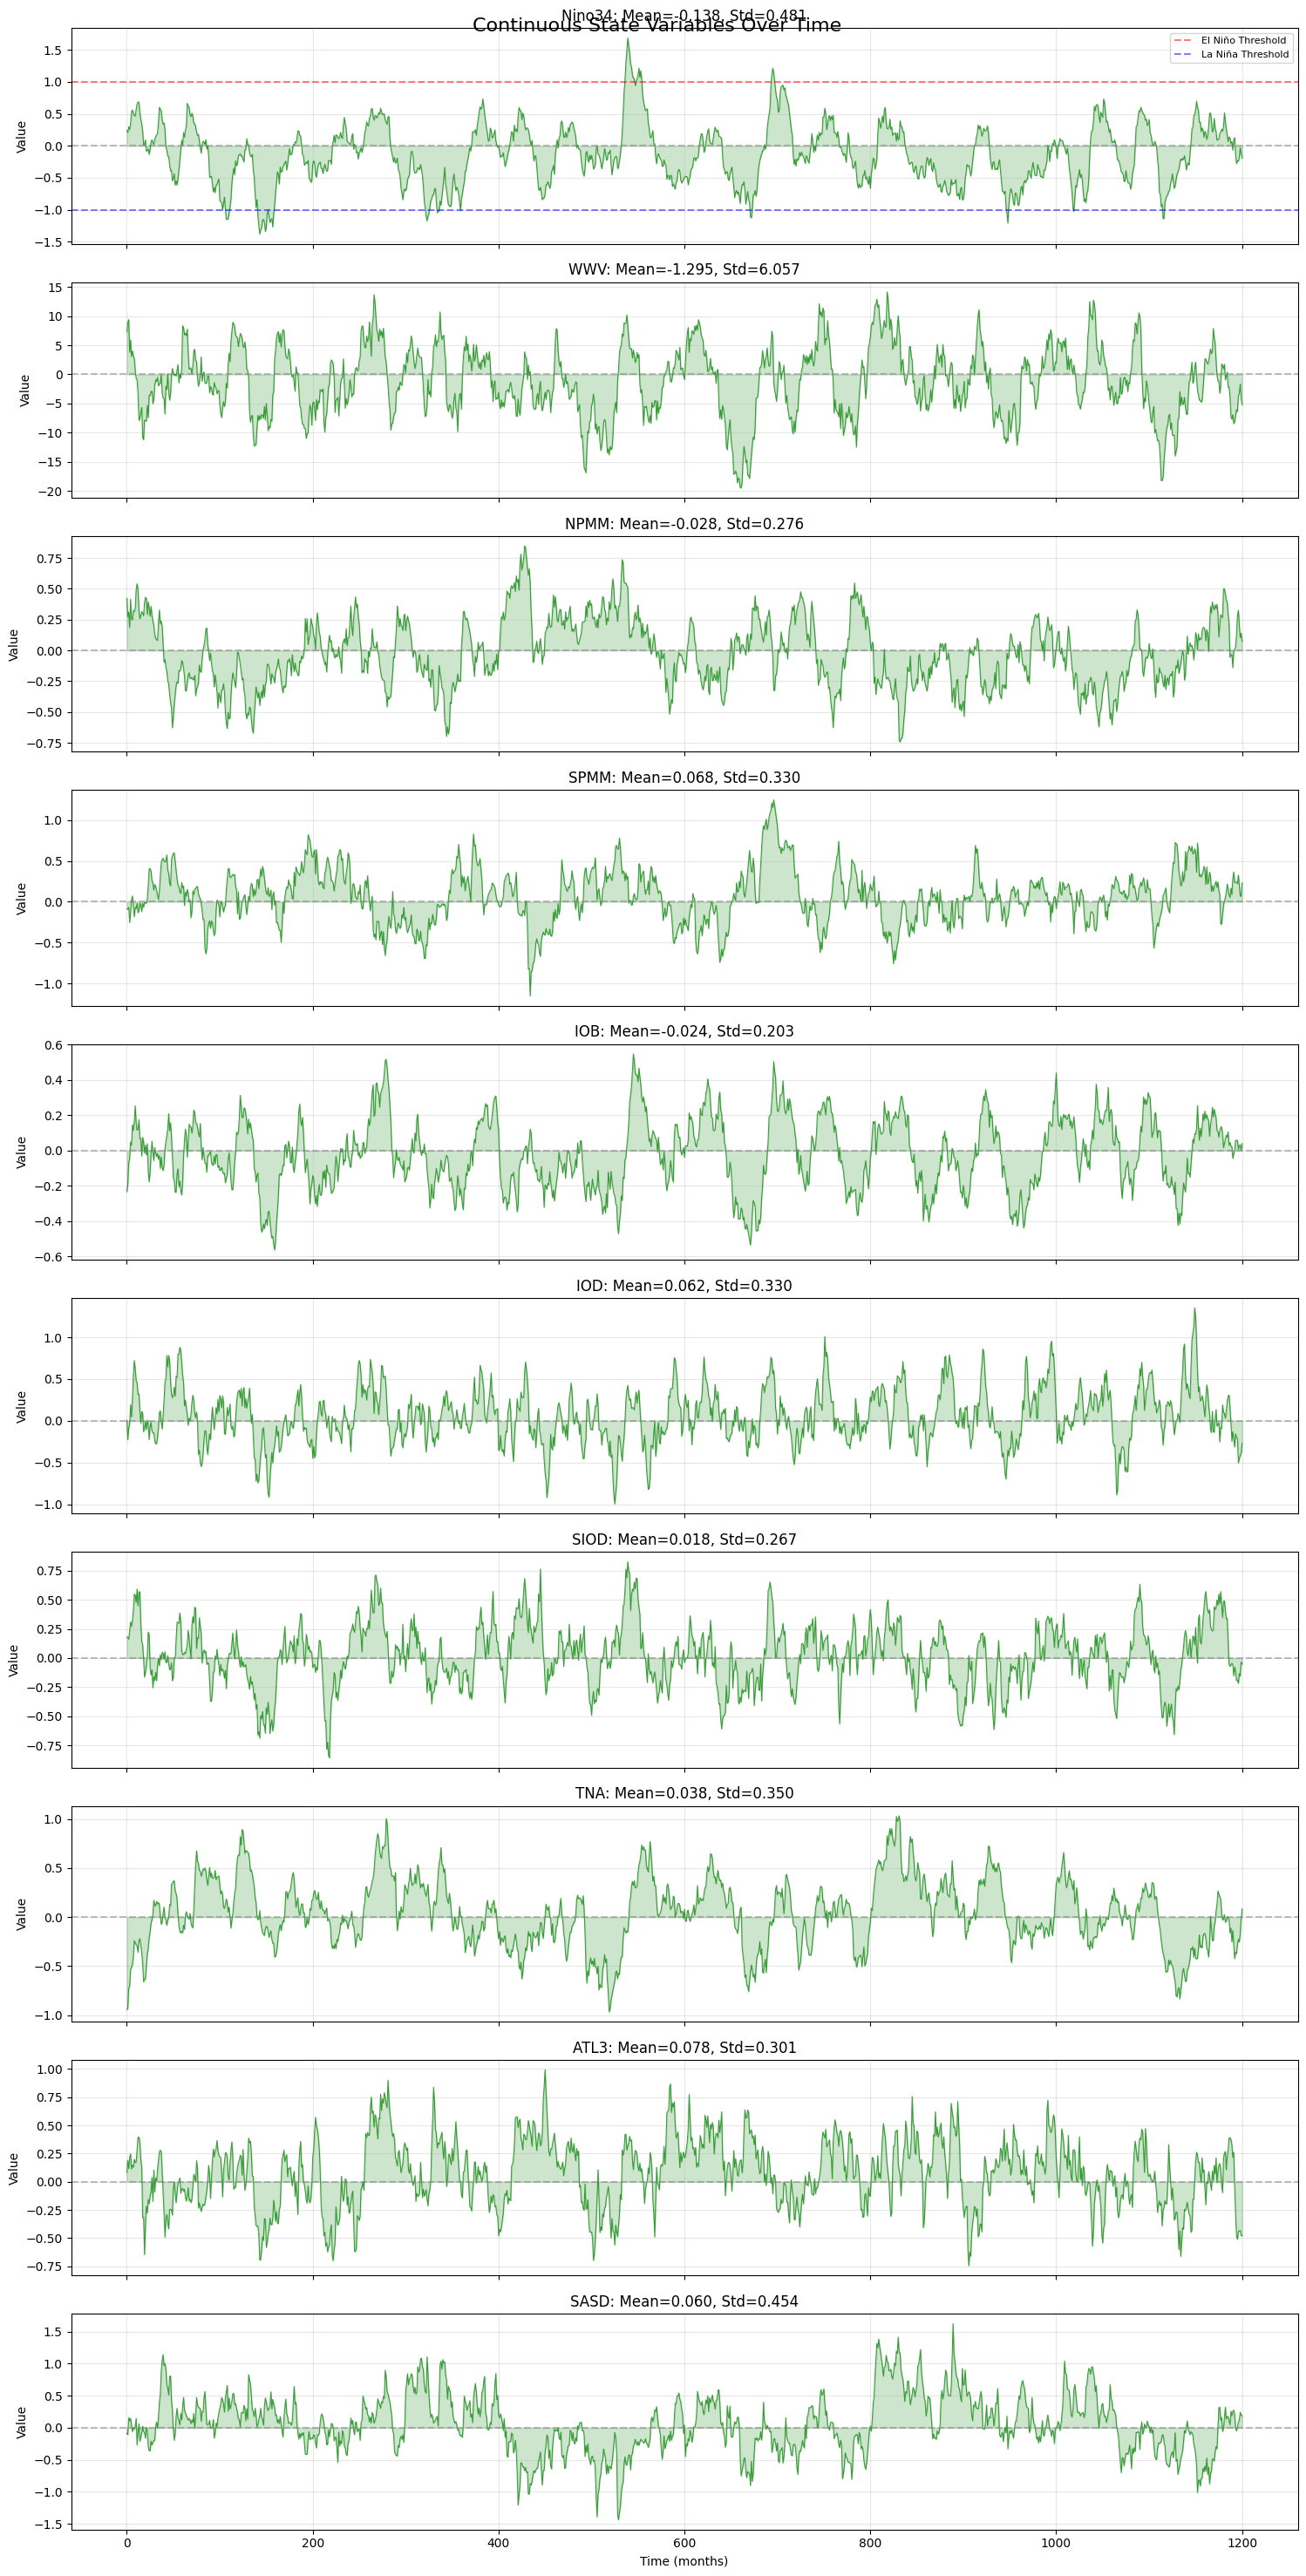


Continuous State Variable Time Series Statistics:

Nino34:
  mean: -0.13812212646007538
  median: -0.1591050922870636
  std: 0.4808095693588257
  min: -1.3782011270523071
  max: 1.6864454746246338
  total_steps: 1201.0000

WWV:
  mean: -1.2950587272644043
  median: -1.2914775609970093
  std: 6.0570268630981445
  min: -19.496118545532227
  max: 14.151618003845215
  total_steps: 1201.0000

NPMM:
  mean: -0.028497401624917984
  median: -0.04737536609172821
  std: 0.2758723199367523
  min: -0.7431700825691223
  max: 0.8481056094169617
  total_steps: 1201.0000

SPMM:
  mean: 0.06792958825826645
  median: 0.06950199604034424
  std: 0.3295361399650574
  min: -1.1518445014953613
  max: 1.246484398841858
  total_steps: 1201.0000

IOB:
  mean: -0.024330435320734978
  median: -0.031666673719882965
  std: 0.20312660932540894
  min: -0.5627633929252625
  max: 0.5475539565086365
  total_steps: 1201.0000

IOD:
  mean: 0.06206265464425087
  median: 0.04698936641216278
  std: 0.32998791337013245
  min

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [ ]:
# CONTINUOUS SIMULATION: Time Series Visualization of State Variables
import seaborn as sns

# Plot continuous time series of state variables
num_states = len(state_var_names)
fig_states, axes_states = plt.subplots(nrows=num_states, ncols=1, figsize=(15, num_states * 3), sharex=True)
fig_states.suptitle('Continuous State Variables Over Time', fontsize=16)

if num_states == 1:
    axes_states = [axes_states]

for i, state_name in enumerate(state_var_names):
    ax = axes_states[i]
    state_ts = states_ts[:, i]
    
    ax.plot(state_ts, linewidth=0.8, alpha=0.7, color='green')
    ax.fill_between(range(len(state_ts)), state_ts, alpha=0.2, color='green')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Add thresholds if ENSO index
    if state_name == 'Nino34':
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='El Niño Threshold')
        ax.axhline(-1.0, color='blue', linestyle='--', alpha=0.5, label='La Niña Threshold')
        ax.legend(loc='upper right', fontsize=8)
    
    ax.set_title(f'{state_name}: Mean={summary_stats_states[state_name]["mean"]:.3f}, Std={summary_stats_states[state_name]["std"]:.3f}')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

axes_states[-1].set_xlabel('Time (months)')
fig_states.tight_layout()
plt.show()

print("\nContinuous State Variable Time Series Statistics:")
for name, stats in summary_stats_states.items():
    print(f"\n{name}:")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value:.4f}" if isinstance(value, (int, float)) else f"  {stat_name}: {value}")


# Kernel Density Estimation (KDE) Analysis by ENSO Event Type

Analyze how the RL agent's control actions and environmental states vary across different ENSO event categories (multi-year El Niño, multi-year La Niña, single-year events, and neutral conditions). KDE plots provide a smooth distribution estimate for each variable within each event type.

In [ ]:
import seaborn as sns

def plot_action_kde_by_event(actions_traj, classified_event_array, action_var_names):
    """
    Plot kernel density estimates for each action variable, grouped by ENSO event type.
    
    Args:
        actions_traj (array): Actions trajectory (num_steps x num_actions)
        classified_event_array (array): Month-by-month event classifications
        action_var_names (list): Action variable names
    """
    num_actions = len(action_var_names)
    
    # Event categories and colors
    event_types = ['Multi-year El Nino', 'Multi-year La Nina', 'Single-year El Nino', 'Single-year La Nina', 'Neutral']
    colors = {'Multi-year El Nino': '#FF6347', 'Multi-year La Nina': '#1E90FF', 
              'Single-year El Nino': '#F4A460', 'Single-year La Nina': '#4682B4', 
              'Neutral': '#95B8D1'}
    
    # Trim classified_event_array to match actions_traj length
    classified_trimmed = classified_event_array[:actions_traj.shape[0]]
    
    # Create subplots
    fig, axes = plt.subplots(nrows=num_actions, ncols=1, figsize=(14, num_actions * 2.5), sharex=False)
    if num_actions == 1:
        axes = [axes]
    
    fig.suptitle('Action Variables Distribution by ENSO Event Type', fontsize=14, fontweight='bold')
    
    # Prepare data for each action
    for i, action_name in enumerate(action_var_names):
        ax = axes[i]
        action_data = actions_traj[:, i]
        
        # Plot KDE for each event type
        for event_type in event_types:
            mask = classified_trimmed == event_type
            if np.sum(mask) > 0:  # Only plot if data exists
                event_actions = action_data[mask]
                sns.kdeplot(data=event_actions, ax=ax, label=event_type, 
                           color=colors.get(event_type, '#000000'), linewidth=2, alpha=0.7)
        
        ax.set_title(f'{action_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Action Value')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')
    
    fig.tight_layout()
    plt.show()


def plot_state_kde_by_event(states_traj, classified_event_array, state_var_names):
    """
    Plot kernel density estimates for each state variable, grouped by ENSO event type.
    
    Args:
        states_traj (array): States trajectory (num_steps x num_variables)
        classified_event_array (array): Month-by-month event classifications
        state_var_names (list): State variable names
    """
    num_vars = len(state_var_names)
    
    # Event categories and colors
    event_types = ['Multi-year El Nino', 'Multi-year La Nina', 'Single-year El Nino', 'Single-year La Nina', 'Neutral']
    colors = {'Multi-year El Nino': '#FF6347', 'Multi-year La Nina': '#1E90FF', 
              'Single-year El Nino': '#F4A460', 'Single-year La Nina': '#4682B4', 
              'Neutral': '#95B8D1'}
    
    # Trim classified_event_array to match states_traj length
    classified_trimmed = classified_event_array[:states_traj.shape[0]]
    
    # Create subplots
    fig, axes = plt.subplots(nrows=num_vars, ncols=1, figsize=(14, num_vars * 2.5), sharex=False)
    if num_vars == 1:
        axes = [axes]
    
    fig.suptitle('State Variables Distribution by ENSO Event Type', fontsize=14, fontweight='bold')
    
    # Prepare data for each state variable
    for i, var_name in enumerate(state_var_names):
        ax = axes[i]
        state_data = states_traj[:, i]
        
        # Plot KDE for each event type
        for event_type in event_types:
            mask = classified_trimmed == event_type
            if np.sum(mask) > 0:  # Only plot if data exists
                event_states = state_data[mask]
                sns.kdeplot(data=event_states, ax=ax, label=event_type, 
                           color=colors.get(event_type, '#000000'), linewidth=2, alpha=0.7)
        
        ax.set_title(f'{var_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Variable Value')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')
    
    fig.tight_layout()
    plt.show()

print("✓ KDE plotting functions defined successfully")

In [ ]:
# Generate KDE plots for control actions by ENSO event type
print("Generating KDE plots for control actions by event type...")
plot_action_kde_by_event(
    actions_ts,
    sim_data['classified_event_array'],
    action_names
)

In [ ]:
# Generate KDE plots for state variables by ENSO event type
print("Generating KDE plots for state variables by event type...")
plot_state_kde_by_event(
    states_ts,
    sim_data['classified_event_array'],
    state_var_names
)

## KDE Plot Interpretation Guide

**Color Legend:**
- **Red (#FF6347)**: Multi-year El Niño distributions
- **Blue (#1E90FF)**: Multi-year La Niña distributions
- **Orange (#F4A460)**: Single-year El Niño distributions
- **Steel Blue (#4682B4)**: Single-year La Niña distributions
- **Light Blue (#95B8D1)**: Neutral state distributions

**What to Look For:**

1. **Action Distributions**: Separate peaks for different event types indicate the agent uses distinct control strategies for various ENSO phases
2. **State Distributions**: Overlapping distributions show system variables can take similar values across multiple event types
3. **Separation Quality**: Well-separated distributions suggest the RL agent strongly differentiates its behavior by event type
4. **Mode Shifts**: Shifts in distribution modes show how the system state changes in response to agent control across event types